# CRANE + Factor-Adjusted Graphical Model: Full Colab Notebook

이 노트북은 한 번에 다음을 수행한다.

1. 관세청 `관세청_품목별 국가별 수출입실적(GW)` API에서 HS 01~99 전체 chapter 데이터를 수집한다.
2. API raw data를 `data_raw/customs_raw_production.csv`로 저장한다.
3. HS-국가-월 수입단가 상대가격 feature와 다음 달 이상충격 target을 만든다.
4. CRANE feature data를 `output_production/crane_features_production.csv`로 저장한다.
5. HS-월 이상점수 행렬을 만들고 Factor model + Graphical LASSO를 적합한다.
6. 그래프 기반 feature를 기존 Tweedie/Hurdle 조기경보 모델에 결합해 baseline과 비교한다.

핵심 모델:

\[
Z_{h,t}=\lambda_h^\top F_t+u_{h,t}, \qquad
u_t \sim N(0,\Sigma_u), \qquad \Omega_u=\Sigma_u^{-1}.
\]

\((\Omega_u)_{ij}\neq 0\)이면 공통요인과 다른 HS를 통제한 뒤에도 HS \(i,j\) 사이에 조건부 의존성이 남는다고 해석한다.

Colab에서 오래 걸리는 작업:

- API 전체 수집: 처음 실행 시 오래 걸림. 이후 cache 재사용.
- LightGBM downstream: 데이터가 크면 오래 걸림.
- Bootstrap edge stability: 기본값 `False`; 최종 실행 때만 `True` 권장.

In [ ]:
# Cell 0. Install and import packages
import importlib.util
import subprocess
import sys
import os
import time
import xml.etree.ElementTree as ET
from getpass import getpass
from pathlib import Path
from urllib.parse import unquote
import warnings

warnings.filterwarnings("ignore")


def ensure_package(import_name, pip_name=None):
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])

for import_name, pip_name in [
    ("numpy", None),
    ("pandas", None),
    ("requests", None),
    ("sklearn", "scikit-learn"),
    ("statsmodels", None),
    ("networkx", None),
    ("matplotlib", None),
    ("seaborn", None),
    ("lightgbm", None),
    ("openpyxl", None),
]:
    ensure_package(import_name, pip_name)

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import lightgbm as lgb

from sklearn.decomposition import PCA
from sklearn.covariance import GraphicalLassoCV, GraphicalLasso
from sklearn.metrics import average_precision_score, roc_auc_score, mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.api import VAR

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 123
EPS = 1e-8

for d in ["data_raw", "data_processed", "output_production", "output_factor_graphical", "figures_production", "figures_factor_graphical"]:
    Path(d).mkdir(exist_ok=True)

print("Packages and folders ready.")
print("Working directory:", os.getcwd())

Packages and folders ready.
Working directory: /content


In [ ]:
# Cell 1. Configuration

# 기본은 API를 다시 따는 모드다. 이미 feature 파일이 있으면 "existing_features"로 바꿔도 된다.
SOURCE_MODE = "customs_api"  # customs_api, existing_features, local_trade

# 이미 저장된 파일 재사용용 경로. customs_api 모드에서는 이 파일을 먼저 찾지 않는다.
LOCAL_FEATURE_PATHS = [
    "output_production/crane_features_production.csv",
    "crane_features_production.csv",
    "crane_features.csv",
]

LOCAL_TRADE_PATHS = [
    "data_raw/customs_raw_production.csv",
    "data_raw/customs_raw.csv",
    "customs_raw_production.csv",
    "customs_raw.csv",
    "trade.csv",
    "trade.xlsx",
]

# Customs API settings
START_YYYYMM = "202001"
END_YYYYMM = "202412"
HS_SCOPE = "all_chapters"  # all_chapters, selected
HS_CODES = [f"{i:02d}" for i in range(1, 100)]
COUNTRY_CODES = [None]  # None: all countries if API accepts omitted cntyCd
CUSTOMS_CACHE_DIR = "data_raw/customs_api_cache"
OVERWRITE_CUSTOMS_CACHE = False
CUSTOMS_SLEEP_SEC = 0.25
CUSTOMS_MAX_RETRIES = 3
CUSTOMS_MAX_PAGES_PER_JOB = None

# CRANE feature settings
ANOMALY_K = 1.5
MIN_COUNTRIES_PER_HS_MONTH = 3
TRAIN_END = "2023-01-01"
VALID_END = "2024-01-01"
MATERIAL_QUANTILE = 0.90
K_VALUES = [10, 30, 50, 100]

# Graph model settings
HS_AGG_METHOD = "value_weighted_abs"
MAX_HS_NODES = 120
MIN_MONTH_COVERAGE = 24
FILL_MISSING_METHOD = "zero_after_standardize"
N_FACTORS = 5
MAX_FACTORS_TO_PLOT = 8
VAR_MAX_LAG = 3
VAR_SELECTED_LAG = None
EDGE_ABS_PARTIAL_CORR_THRESHOLD = 0.05
TOP_EDGES_TO_PLOT = 180
RUN_BOOTSTRAP_STABILITY = False  # Colab-safe. 최종 발표용만 True 권장.
BOOTSTRAP_B = 50
BOOTSTRAP_BLOCK_SIZE = 6
EDGE_STABILITY_THRESHOLD = 0.50

# Downstream prediction settings
RUN_DOWNSTREAM_LIGHTGBM = True

# Plot settings
SAVE_FIGURES = True
FIG_DPI = 140

print("Configuration loaded.")

Configuration loaded.


In [ ]:
# Cell 2. General helper functions

def read_table_auto(path_or_url):
    path_or_url = str(path_or_url)
    lower = path_or_url.lower()
    if lower.startswith("http://") or lower.startswith("https://"):
        if lower.endswith((".xlsx", ".xls")):
            return pd.read_excel(path_or_url)
        return pd.read_csv(path_or_url)
    path = Path(path_or_url)
    if not path.exists():
        raise FileNotFoundError(path)
    if lower.endswith((".xlsx", ".xls")):
        return pd.read_excel(path)
    if lower.endswith(".parquet"):
        return pd.read_parquet(path)
    if lower.endswith(".zip"):
        return pd.read_csv(path, compression="zip")
    try:
        return pd.read_csv(path, encoding="utf-8-sig")
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="cp949")


def first_existing(paths):
    for p in paths:
        if Path(p).exists():
            return p
    return None


def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace(" ", "", regex=False)
        .str.strip(),
        errors="coerce",
    )


def pick_column(df, candidates):
    lower_map = {str(c).lower().strip(): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().strip()
        if key in lower_map:
            return lower_map[key]
    return None


def robust_mad(x):
    arr = pd.Series(x).dropna().to_numpy(dtype=float)
    if len(arr) == 0:
        return np.nan
    med = np.nanmedian(arr)
    return np.nanmedian(np.abs(arr - med))


def save_fig(path, min_bytes=3000):
    path = Path(path)
    if SAVE_FIGURES:
        plt.tight_layout()
        plt.savefig(path, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
    if SAVE_FIGURES:
        if not path.exists() or path.stat().st_size < min_bytes:
            print(f"WARNING: figure may be too small or not saved correctly: {path}")
        else:
            print("saved figure:", path, "bytes=", path.stat().st_size)


def pct_rank_score(x):
    return pd.Series(x).rank(pct=True).fillna(0.5).to_numpy()


def safe_zscore_matrix(mat):
    out = mat.copy().astype(float)
    mu = out.mean(axis=0, skipna=True)
    sd = out.std(axis=0, skipna=True).replace(0, np.nan)
    out = (out - mu) / sd
    return out, mu, sd

print("Helpers ready.")

Helpers ready.


In [ ]:
# Cell 3. Customs API functions

def make_yearly_periods(start_yyyymm, end_yyyymm):
    start_year = int(start_yyyymm[:4])
    end_year = int(end_yyyymm[:4])
    periods = []
    for year in range(start_year, end_year + 1):
        start_month = int(start_yyyymm[4:6]) if year == start_year else 1
        end_month = int(end_yyyymm[4:6]) if year == end_year else 12
        periods.append((f"{year}{start_month:02d}", f"{year}{end_month:02d}"))
    return periods


def resolve_hs_codes():
    if HS_SCOPE == "all_chapters":
        return [f"{i:02d}" for i in range(1, 100)]
    if HS_SCOPE == "selected":
        return [str(x).zfill(2) if str(x).isdigit() and len(str(x)) == 1 else str(x) for x in HS_CODES]
    raise ValueError("HS_SCOPE must be 'all_chapters' or 'selected'.")


def safe_cache_name(hs_code, country_code, start_yyyymm, end_yyyymm):
    country = country_code if country_code not in (None, "") else "ALL"
    return f"customs_hs_{hs_code}_country_{country}_{start_yyyymm}_{end_yyyymm}.csv"


def call_customs_api_xml(service_key, start_yyyymm, end_yyyymm, hs_code=None, country_code=None, page_no=1, num_rows=10000):
    base_url = "https://apis.data.go.kr/1220000/nitemtrade/getNitemtradeList"
    params = {
        "serviceKey": service_key,
        "strtYymm": start_yyyymm,
        "endYymm": end_yyyymm,
        "pageNo": page_no,
        "numOfRows": num_rows,
    }
    if hs_code:
        params["hsSgn"] = str(hs_code)
    if country_code:
        params["cntyCd"] = str(country_code)
    response = requests.get(base_url, params=params, timeout=90)
    if response.status_code != 200:
        raise RuntimeError(f"Customs HTTP {response.status_code}: {response.text[:500]}")
    return response.text


def parse_customs_xml(xml_text):
    root = ET.fromstring(xml_text)
    result_code = root.findtext(".//resultCode")
    result_msg = root.findtext(".//resultMsg")
    if result_code not in (None, "00"):
        raise RuntimeError(f"Customs API resultCode={result_code}, resultMsg={result_msg}")
    total_text = root.findtext(".//totalCount")
    total_count = int(total_text) if total_text else None
    rows = [{child.tag: child.text for child in item} for item in root.findall(".//item")]
    return pd.DataFrame(rows), total_count


def collect_customs_api(
    service_key,
    hs_codes,
    start_yyyymm,
    end_yyyymm,
    country_codes=(None,),
    cache_dir=CUSTOMS_CACHE_DIR,
    overwrite_cache=OVERWRITE_CUSTOMS_CACHE,
    sleep_sec=CUSTOMS_SLEEP_SEC,
    max_retries=CUSTOMS_MAX_RETRIES,
    max_pages_per_job=CUSTOMS_MAX_PAGES_PER_JOB,
):
    periods = make_yearly_periods(start_yyyymm, end_yyyymm)
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    frames = []
    failures = []

    for hs in hs_codes:
        for country in country_codes:
            for start, end in periods:
                cache_path = cache_dir / safe_cache_name(hs, country, start, end)
                if cache_path.exists() and not overwrite_cache:
                    try:
                        cached = read_table_auto(cache_path)
                        frames.append(cached)
                        print(f"Cache hit: hs={hs}, country={country or 'ALL'}, {start}-{end}, rows={len(cached)}")
                        continue
                    except Exception as err:
                        print("Cache read failed, refetching:", cache_path, err)

                page = 1
                job_pages = []
                while True:
                    try:
                        df_page = pd.DataFrame()
                        total_count = None
                        last_error = None
                        for attempt in range(1, max_retries + 1):
                            try:
                                xml_text = call_customs_api_xml(service_key, start, end, hs, country, page_no=page)
                                df_page, total_count = parse_customs_xml(xml_text)
                                break
                            except Exception as err:
                                last_error = err
                                wait = sleep_sec * attempt
                                print(f"Retry {attempt}/{max_retries}: hs={hs}, {start}-{end}, page={page}, error={err}")
                                time.sleep(wait)
                        else:
                            raise RuntimeError(last_error)

                        if df_page.empty:
                            break

                        df_page["query_hs_code"] = hs
                        df_page["query_country_code"] = country if country else ""
                        df_page["query_start_yyyymm"] = start
                        df_page["query_end_yyyymm"] = end
                        df_page["query_page_no"] = page
                        job_pages.append(df_page)
                        print(f"Customs hs={hs}, country={country or 'ALL'}, {start}-{end}, page={page}, rows={len(df_page)}, total={total_count}")

                        if max_pages_per_job is not None and page >= max_pages_per_job:
                            print("Stopped by CUSTOMS_MAX_PAGES_PER_JOB for debugging.")
                            break
                        if total_count is None or page * 10000 >= total_count:
                            break
                        page += 1
                        time.sleep(sleep_sec)
                    except Exception as err:
                        failures.append({
                            "hs_code": hs,
                            "country_code": country,
                            "start_yyyymm": start,
                            "end_yyyymm": end,
                            "page": page,
                            "error": str(err),
                        })
                        print("Customs failure:", failures[-1])
                        break

                if job_pages:
                    job_df = pd.concat(job_pages, ignore_index=True)
                    job_df.to_csv(cache_path, index=False, encoding="utf-8-sig")
                    frames.append(job_df)

    raw = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    failed = pd.DataFrame(failures)
    raw.to_csv("data_raw/customs_raw_production.csv", index=False, encoding="utf-8-sig")
    failed.to_csv("data_raw/customs_failed_jobs_production.csv", index=False, encoding="utf-8-sig")
    return raw, failed

print("Customs API functions ready.")

Customs API functions ready.


In [ ]:
# Cell 4. Standardize Customs/API/local trade data

def standardize_trade_dataframe(df):
    """Standardize Customs/API/local trade data to HS-country-month cells."""
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]

    col_date = pick_column(out, ["date", "ym", "year_month", "yearmonth", "time", "TIME", "period"])
    col_year = pick_column(out, ["year", "YEAR"])
    col_hs = pick_column(out, ["hs_code", "hsCd", "hscd", "hs", "hsSgn", "cmdCode", "commodity_code"])
    col_country = pick_column(out, ["country_code", "statCd", "cntyCd", "partnerCode", "partner_code", "country"])
    col_country_name = pick_column(out, ["country_name", "statCdCntnKor1", "partnerDesc", "partner_name"])
    col_hs_name = pick_column(out, ["hs_name", "statKor", "cmdDesc", "commodity"])
    col_value = pick_column(out, ["import_value", "impDlr", "importValue", "tradeValue", "cifvalue", "value"])
    col_weight = pick_column(out, ["import_weight", "impWgt", "netWgt", "net_weight", "weight"])

    required = {"HS": col_hs, "country": col_country, "value": col_value, "weight": col_weight}
    missing = [k for k, v in required.items() if v is None]
    if missing:
        raise KeyError(f"Required columns could not be identified: {missing}. Available columns: {list(out.columns)[:80]}")

    if col_date is not None:
        date_raw = out[col_date].astype(str).str.strip()
    elif col_year is not None:
        date_raw = out[col_year].astype(str).str.strip()
    else:
        raise KeyError("Could not identify date/year_month column.")

    date_raw = date_raw.str.replace(".", "", regex=False).str.replace("-", "", regex=False).str.replace("/", "", regex=False)
    ym = date_raw.str.extract(r"(\d{6})", expand=False)
    out["date"] = pd.to_datetime(ym + "01", format="%Y%m%d", errors="coerce")

    out["hs_code"] = out[col_hs].astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
    out["country_code"] = out[col_country].astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
    out["country_name"] = out[col_country_name].astype(str).str.strip() if col_country_name else out["country_code"]
    out["hs_name"] = out[col_hs_name].astype(str).str.strip() if col_hs_name else out["hs_code"]
    out["import_value"] = clean_numeric(out[col_value])
    out["import_weight"] = clean_numeric(out[col_weight])

    out = out[
        out["date"].notna()
        & out["hs_code"].notna()
        & out["country_code"].notna()
        & (out["hs_code"] != "-")
        & (out["country_code"] != "-")
        & out["import_value"].notna()
        & out["import_weight"].notna()
        & (out["import_value"] > 0)
        & (out["import_weight"] > 0)
    ].copy()

    agg = (
        out.groupby(["date", "hs_code", "country_code"], as_index=False)
        .agg(
            country_name=("country_name", "first"),
            hs_name=("hs_name", "first"),
            import_value=("import_value", "sum"),
            import_weight=("import_weight", "sum"),
        )
        .sort_values(["hs_code", "country_code", "date"])
    )
    agg["year_month"] = agg["date"].dt.strftime("%Y%m")
    agg["year"] = agg["date"].dt.year
    agg["month"] = agg["date"].dt.month
    agg["unit_price"] = agg["import_value"] / agg["import_weight"]
    agg["log_price"] = np.log(agg["unit_price"])
    agg = agg.replace([np.inf, -np.inf], np.nan).dropna(subset=["log_price"])
    return agg.reset_index(drop=True)


def diagnose_hs_scope(df, label):
    if "hs_code" not in df.columns:
        return
    hs = df["hs_code"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(4)
    chapters = hs.str[:2]
    summary = pd.DataFrame({
        "metric": ["rows", "unique_hs_codes", "unique_hs_chapters", "min_chapter", "max_chapter"],
        "value": [len(df), hs.nunique(), chapters.nunique(), chapters.min(), chapters.max()],
    })
    print(f"HS scope diagnostic: {label}")
    display(summary)
    display(chapters.value_counts().sort_index().rename_axis("hs_chapter").reset_index(name="rows"))

print("Standardization functions ready.")

Standardization functions ready.


In [ ]:
# Cell 5. Load data from API or existing file
# customs_api 모드에서는 local CSV를 먼저 찾지 않고 API를 실행한다.

if SOURCE_MODE == "customs_api":
    active_hs_codes = resolve_hs_codes()
    print(
        f"Customs API production collection: HS_SCOPE={HS_SCOPE}, "
        f"HS jobs={len(active_hs_codes)}, period={START_YYYYMM}-{END_YYYYMM}. "
        "Cached jobs are reused unless OVERWRITE_CUSTOMS_CACHE=True."
    )
    raw_key = getpass("Public Data Portal service key: ").strip()
    raw = pd.DataFrame()
    last_error = None
    for key in [unquote(raw_key), raw_key]:
        try:
            raw, failed = collect_customs_api(
                key,
                hs_codes=active_hs_codes,
                start_yyyymm=START_YYYYMM,
                end_yyyymm=END_YYYYMM,
                country_codes=COUNTRY_CODES,
            )
            if not raw.empty:
                break
        except Exception as err:
            last_error = err
            print("Key attempt failed:", err)
    if raw.empty:
        raise RuntimeError(f"Customs API collection failed: {last_error}")
    crane_or_trade = standardize_trade_dataframe(raw)
    print("Collected and standardized trade data from Customs API.")

elif SOURCE_MODE == "existing_features":
    feature_path = first_existing(LOCAL_FEATURE_PATHS)
    if feature_path is None:
        raise FileNotFoundError(f"No existing feature file found in: {LOCAL_FEATURE_PATHS}")
    crane_or_trade = read_table_auto(feature_path)
    crane_or_trade["date"] = pd.to_datetime(crane_or_trade["date"], errors="coerce")
    if "next_date" in crane_or_trade.columns:
        crane_or_trade["next_date"] = pd.to_datetime(crane_or_trade["next_date"], errors="coerce")
    print(f"Loaded existing feature file: {feature_path}")

elif SOURCE_MODE == "local_trade":
    trade_path = first_existing(LOCAL_TRADE_PATHS)
    if trade_path is None:
        raise FileNotFoundError(f"No local trade file found in: {LOCAL_TRADE_PATHS}")
    raw_local = read_table_auto(trade_path)
    crane_or_trade = standardize_trade_dataframe(raw_local)
    print(f"Loaded raw trade file: {trade_path}")

else:
    raise ValueError("SOURCE_MODE must be customs_api, existing_features, or local_trade.")

print("loaded shape:", crane_or_trade.shape)
display(crane_or_trade.head())
diagnose_hs_scope(crane_or_trade, "loaded input")

# Save standardized trade frame as a stable intermediate.
if not {"rel_z", "future_net_anomaly_amount"}.issubset(crane_or_trade.columns):
    crane_or_trade.to_csv("data_processed/trade_clean_production.csv", index=False, encoding="utf-8-sig")
    print("Saved standardized trade frame: data_processed/trade_clean_production.csv")

Customs API production collection: HS_SCOPE=all_chapters, HS jobs=99, period=202001-202412. Cached jobs are reused unless OVERWRITE_CUSTOMS_CACHE=True.
Public Data Portal service key: ··········
Customs hs=01, country=ALL, 202001-202012, page=1, rows=599, total=None
Customs hs=01, country=ALL, 202101-202112, page=1, rows=696, total=None
Customs hs=01, country=ALL, 202201-202212, page=1, rows=653, total=None
Customs hs=01, country=ALL, 202301-202312, page=1, rows=671, total=None
Customs hs=01, country=ALL, 202401-202412, page=1, rows=642, total=None
Customs hs=02, country=ALL, 202001-202012, page=1, rows=901, total=None
Customs hs=02, country=ALL, 202101-202112, page=1, rows=905, total=None
Customs hs=02, country=ALL, 202201-202212, page=1, rows=914, total=None
Customs hs=02, country=ALL, 202301-202312, page=1, rows=875, total=None
Customs hs=02, country=ALL, 202401-202412, page=1, rows=983, total=None
Customs hs=03, country=ALL, 202001-202012, page=1, rows=3520, total=None
Customs hs=0

,date,hs_code,country_code,country_name,hs_name,import_value,import_weight,year_month,year,month,unit_price,log_price
0,2020-06-01,0101,AR,아르헨티나,살아 있는 말ㆍ당나귀ㆍ노새ㆍ버새,244500,4000,202006,2020,6,61.125000,4.112921
1,2021-03-01,0101,AR,아르헨티나,살아 있는 말ㆍ당나귀ㆍ노새ㆍ버새,434300,4000,202103,2021,3,108.575000,4.687441
2,2021-04-01,0101,AR,아르헨티나,살아 있는 말ㆍ당나귀ㆍ노새ㆍ버새,266700,4000,202104,2021,4,66.675000,4.199830
3,2021-08-01,0101,AR,아르헨티나,살아 있는 말ㆍ당나귀ㆍ노새ㆍ버새,88600,1200,202108,2021,8,73.833333,4.301810
4,2022-05-01,0101,AR,아르헨티나,살아 있는 말ㆍ당나귀ㆍ노새ㆍ버새,673000,6750,202205,2022,5,99.703704,4.602203


HS scope diagnostic: loaded input


,metric,value
0,rows,1409337
1,unique_hs_codes,1229
2,unique_hs_chapters,97
3,min_chapter,01
4,max_chapter,99


,hs_chapter,rows
0,01,2488
1,02,3984
2,03,12980
3,04,8929
4,05,3483
...,...,...
92,94,14291
93,95,12946
94,96,22062
95,97,5545


Saved standardized trade frame: data_processed/trade_clean_production.csv


In [ ]:
# Cell 6. CRANE feature engineering

def leave_one_out_median_series(s):
    vals = s.to_numpy(dtype=float)
    n = len(vals)
    if n <= 2:
        return pd.Series(np.nan, index=s.index)
    result = np.empty(n, dtype=float)
    for i in range(n):
        result[i] = np.nanmedian(np.delete(vals, i))
    return pd.Series(result, index=s.index)


def isolation_score_series(s, eps=EPS):
    vals = s.to_numpy(dtype=float)
    n = len(vals)
    if n <= 2:
        return pd.Series(np.nan, index=s.index)
    scale = robust_mad(vals)
    if not np.isfinite(scale) or scale <= 0:
        scale = np.nanstd(vals)
    scale = max(float(scale), eps)
    dist = np.abs(vals[:, None] - vals[None, :])
    sim = np.exp(-dist / scale)
    np.fill_diagonal(sim, np.nan)
    return pd.Series(1.0 - np.nanmean(sim, axis=1), index=s.index)


def add_crane_features(trade, k=ANOMALY_K, min_countries=MIN_COUNTRIES_PER_HS_MONTH):
    out = trade.copy()
    if "unit_price" not in out.columns or "log_price" not in out.columns:
        out = standardize_trade_dataframe(out)
    out["date"] = pd.to_datetime(out["date"])
    out["hs_code"] = out["hs_code"].astype(str)
    out["country_code"] = out["country_code"].astype(str)
    out = out.sort_values(["hs_code", "country_code", "date"]).reset_index(drop=True)

    group_cols = ["hs_code", "date"]
    grp = out.groupby(group_cols)["log_price"]
    out["ht_country_count"] = grp.transform("count")
    out["ht_median_log_price"] = grp.transform("median")
    out["ht_mad_log_price"] = grp.transform(lambda x: robust_mad(x)).clip(lower=EPS)
    out["rel_z"] = (out["log_price"] - out["ht_median_log_price"]) / out["ht_mad_log_price"]

    rank = grp.rank(method="average")
    out["price_rank_pct"] = np.where(out["ht_country_count"] > 1, (rank - 1) / (out["ht_country_count"] - 1), np.nan)
    out.loc[out["ht_country_count"] < min_countries, ["rel_z", "price_rank_pct"]] = np.nan

    out["loo_median_log_price"] = (
        out.groupby(group_cols)["log_price"].apply(leave_one_out_median_series).reset_index(level=group_cols, drop=True)
    )
    out["counterfactual_dev"] = out["log_price"] - out["loo_median_log_price"]
    out["counterfactual_dev_scaled"] = out["counterfactual_dev"] / out["ht_mad_log_price"]
    out["network_isolation_score"] = (
        out.groupby(group_cols)["log_price"].apply(isolation_score_series).reset_index(level=group_cols, drop=True)
    )

    out["total_hs_month_import"] = out.groupby(group_cols)["import_value"].transform("sum")
    out["import_share_country"] = out["import_value"] / out["total_hs_month_import"]
    out["hhi_hs_month"] = out.groupby(group_cols)["import_share_country"].transform(lambda x: float(np.sum(np.square(x))))
    out["concentration_risk"] = out["import_share_country"] * out["hhi_hs_month"]

    panel = out.groupby(["hs_code", "country_code"], group_keys=False)
    out["lag_date"] = panel["date"].shift(1)
    out["price_return"] = panel["log_price"].diff()
    out["rank_shift"] = out["price_rank_pct"] - panel["price_rank_pct"].shift(1)
    continuous_lag = out["date"].eq(out["lag_date"] + pd.DateOffset(months=1))
    out.loc[~continuous_lag, ["price_return", "rank_shift"]] = np.nan

    out["abs_rank_shift"] = out["rank_shift"].abs()
    out["import_growth"] = panel["import_value"].pct_change()
    out["weight_growth"] = panel["import_weight"].pct_change()
    out["log_import_value"] = np.log(out["import_value"])
    out["log_import_weight"] = np.log(out["import_weight"])
    out["abs_rel_z"] = out["rel_z"].abs()

    out["anomaly_abs"] = (out["rel_z"].abs() > k).astype(float)
    out["anomaly_up"] = (out["rel_z"] > k).astype(float)
    out["anomaly_down"] = (out["rel_z"] < -k).astype(float)

    for col in ["anomaly_abs", "anomaly_up", "anomaly_down", "abs_rel_z"]:
        out[f"{col}_roll3"] = panel[col].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())

    out["price_return_roll3"] = panel["price_return"].transform(lambda x: x.shift(1).rolling(3, min_periods=2).mean())
    out["price_volatility_roll3"] = panel["price_return"].transform(lambda x: x.shift(1).rolling(3, min_periods=2).std())
    out["import_growth_roll3"] = panel["import_growth"].transform(lambda x: x.shift(1).rolling(3, min_periods=2).mean())

    out["return_sign"] = np.sign(out["price_return"])

    def majority_sign(x):
        nonzero = x.dropna()
        nonzero = nonzero[nonzero != 0]
        if len(nonzero) == 0:
            return np.nan
        return 1.0 if (nonzero > 0).mean() >= 0.5 else -1.0

    out["majority_sign"] = out.groupby(group_cols)["return_sign"].transform(majority_sign)
    out["sync_score"] = out.groupby(group_cols)["return_sign"].transform(
        lambda x: np.nan if x.dropna().empty else np.nanmean(x == out.loc[x.index, "majority_sign"])
    )
    out["idiosyncratic_current_score"] = out["abs_rel_z"] * (1 - out["sync_score"].fillna(0))

    stats = (
        out.groupby(group_cols, as_index=False)
        .agg(
            ht_median_for_shift=("log_price", "median"),
            ht_mad_for_shift=("log_price", robust_mad),
            ht_total_import_value=("import_value", "sum"),
        )
        .sort_values(["hs_code", "date"])
    )
    stats["ht_median_return"] = stats.groupby("hs_code")["ht_median_for_shift"].diff()
    stats["ht_mad_return"] = stats.groupby("hs_code")["ht_mad_for_shift"].diff()
    stats["total_import_return"] = stats.groupby("hs_code")["ht_total_import_value"].pct_change()
    stats["price_distribution_shift"] = (
        stats["ht_median_return"].abs() / (stats["ht_mad_for_shift"].abs() + EPS)
        + stats["ht_mad_return"].abs() / (stats["ht_mad_for_shift"].abs() + EPS)
    )
    out = out.merge(
        stats[["hs_code", "date", "ht_median_return", "ht_mad_return", "total_import_return", "price_distribution_shift"]],
        on=group_cols,
        how="left",
    )

    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    return out.replace([np.inf, -np.inf], np.nan)


def add_future_targets(df, k=ANOMALY_K):
    out = df.copy().sort_values(["hs_code", "country_code", "date"]).reset_index(drop=True)
    panel = out.groupby(["hs_code", "country_code"], group_keys=False)
    out["next_date"] = panel["date"].shift(-1)
    out["next_rel_z"] = panel["rel_z"].shift(-1)
    out["next_price_rank_pct"] = panel["price_rank_pct"].shift(-1)
    if "network_isolation_score" in out.columns:
        out["next_network_isolation_score"] = panel["network_isolation_score"].shift(-1)
    out["has_next_month"] = out["next_date"].eq(out["date"] + pd.DateOffset(months=1))

    excess_abs = np.maximum(out["next_rel_z"].abs() - k, 0)
    excess_up = np.maximum(out["next_rel_z"] - k, 0)
    excess_down = np.maximum(-out["next_rel_z"] - k, 0)

    out["future_abs_anomaly"] = np.where(out["has_next_month"], excess_abs, np.nan)
    out["future_up_anomaly"] = np.where(out["has_next_month"], excess_up, np.nan)
    out["future_down_anomaly"] = np.where(out["has_next_month"], excess_down, np.nan)
    out["future_net_anomaly_amount"] = out["import_value"] * out["future_abs_anomaly"]
    out["future_up_anomaly_amount"] = out["import_value"] * out["future_up_anomaly"]
    out["future_down_anomaly_amount"] = out["import_value"] * out["future_down_anomaly"]
    return out

needed = {"rel_z", "future_net_anomaly_amount", "import_value", "import_weight", "hs_code", "country_code", "date"}
if needed.issubset(set(crane_or_trade.columns)):
    crane = crane_or_trade.copy()
    print("Existing CRANE features detected and reused.")
else:
    trade_clean = standardize_trade_dataframe(crane_or_trade) if "unit_price" not in crane_or_trade.columns else crane_or_trade.copy()
    crane = add_crane_features(trade_clean)
    crane = add_future_targets(crane)
    print("CRANE features created from trade data.")

if "future_net_anomaly_amount" not in crane.columns:
    crane = add_future_targets(crane)

crane["date"] = pd.to_datetime(crane["date"])
crane["hs_code"] = crane["hs_code"].astype(str)
crane["country_code"] = crane["country_code"].astype(str)
crane.to_csv("output_production/crane_features_production.csv", index=False, encoding="utf-8-sig")
print("Saved CRANE feature file: output_production/crane_features_production.csv")
print("crane shape:", crane.shape)
display(crane.head())
diagnose_hs_scope(crane, "CRANE feature frame")

CRANE features created from trade data.
Saved CRANE feature file: output_production/crane_features_production.csv
crane shape: (1409337, 65)


,date,hs_code,country_code,country_name,hs_name,import_value,import_weight,year_month,year,month,unit_price,log_price,ht_country_count,ht_median_log_price,ht_mad_log_price,rel_z,price_rank_pct,loo_median_log_price,counterfactual_dev,counterfactual_dev_scaled,network_isolation_score,total_hs_month_import,import_share_country,hhi_hs_month,concentration_risk,lag_date,price_return,rank_shift,abs_rank_shift,import_growth,weight_growth,log_import_value,log_import_weight,abs_rel_z,anomaly_abs,anomaly_up,anomaly_down,anomaly_abs_roll3,anomaly_up_roll3,anomaly_down_roll3,abs_rel_z_roll3,price_return_roll3,price_volatility_roll3,import_growth_roll3,return_sign,majority_sign,sync_score,idiosyncratic_current_score,ht_median_return,ht_mad_return,total_import_return,price_distribution_shift,month_sin,month_cos,next_date,next_rel_z,next_price_rank_pct,next_network_isolation_score,has_next_month,future_abs_anomaly,future_up_anomaly,future_down_anomaly,future_net_anomaly_amount,future_up_anomaly_amount,future_down_anomaly_amount
0,2020-06-01,0101,AR,아르헨티나,살아 있는 말ㆍ당나귀ㆍ노새ㆍ버새,244500,4000,202006,2020,6,61.125000,4.112921,2,4.527626,0.414705,NaN,NaN,NaN,NaN,NaN,NaN,664789,0.367786,0.534961,0.196751,NaT,NaN,NaN,NaN,NaN,NaN,12.406971,8.294050,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.500000,NaN,0.086364,0.395163,-0.736557,1.161132,1.224647e-16,-1.000000e+00,2021-03-01,1.973954,1.000000,0.905979,False,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-03-01,0101,AR,아르헨티나,살아 있는 말ㆍ당나귀ㆍ노새ㆍ버새,434300,4000,202103,2021,3,108.575000,4.687441,4,4.459710,0.115368,1.973954,1.0,4.456706,0.230736,2.000000,0.905979,1729062,0.251177,0.365315,0.091759,2020-06-01,NaN,NaN,NaN,0.776278,0.000,12.981491,8.294050,1.973954,1.0,1.0,0.0,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.973954,0.926199,0.115368,49.492407,9.028226,1.000000e+00,6.123234e-17,2021-04-01,-1.000000,0.000000,0.763820,True,0.0,0.0,0.0,0.0,0.0,0.0
2,2021-04-01,0101,AR,아르헨티나,살아 있는 말ㆍ당나귀ㆍ노새ㆍ버새,266700,4000,202104,2021,4,66.675000,4.199830,3,4.677608,0.477778,-1.000000,0.0,4.978310,-0.778480,-1.629376,0.763820,1086659,0.245431,0.369190,0.090611,2021-03-01,-0.487611,-1.0,1.0,-0.385908,0.000,12.493880,8.294050,1.000000,0.0,0.0,0.0,0.500000,0.500000,0.0,1.973954,NaN,NaN,NaN,-1.0,1.0,0.666667,0.333333,0.217898,0.362410,-0.371533,1.214597,8.660254e-01,-5.000000e-01,2021-08-01,1.000000,1.000000,0.816018,False,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-08-01,0101,AR,아르헨티나,살아 있는 말ㆍ당나귀ㆍ노새ㆍ버새,88600,1200,202108,2021,8,73.833333,4.301810,3,4.248052,0.053758,1.000000,1.0,4.022631,0.279179,5.193251,0.816018,225434,0.393020,0.338772,0.133144,2021-04-01,NaN,NaN,NaN,-0.667792,-0.700,11.391887,7.090077,1.000000,0.0,0.0,0.0,0.333333,0.333333,0.0,1.486977,NaN,NaN,0.195185,NaN,-1.0,0.666667,0.333333,0.159602,-0.138259,-0.582493,5.540785,-8.660254e-01,-5.000000e-01,2022-05-01,1.367598,1.000000,0.791229,False,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-05-01,0101,AR,아르헨티나,살아 있는 말ㆍ당나귀ㆍ노새ㆍ버새,673000,6750,202205,2022,5,99.703704,4.602203,4,4.231371,0.271156,1.367598,1.0,4.059891,0.542312,2.000000,0.791229,1021417,0.658889,0.497800,0.327995,2021-08-01,NaN,NaN,NaN,6.595937,4.625,13.419501,8.817298,1.367598,0.0,0.0,0.0,0.333333,0.333333,0.0,1.324651,NaN,NaN,-0.092474,NaN,1.0,0.500000,0.683799,0.805416,0.108805,2.551075,3.371569,5.000000e-01,-8.660254e-01,2022-07-01,0.792540,0.666667,0.700525,False,NaN,NaN,NaN,NaN,NaN,NaN


HS scope diagnostic: CRANE feature frame


,metric,value
0,rows,1409337
1,unique_hs_codes,1229
2,unique_hs_chapters,97
3,min_chapter,01
4,max_chapter,99


,hs_chapter,rows
0,01,2488
1,02,3984
2,03,12980
3,04,8929
4,05,3483
...,...,...
92,94,14291
93,95,12946
94,96,22062
95,97,5545


Data shape: (1409337, 65)
Date range: 2020-01-01 00:00:00 to 2024-12-01 00:00:00
Number of months: 60
Unique HS codes: 1229
Unique HS chapters: 97
Unique countries: 249
Missing target ratio: 0.21512101080153292
Zero target ratio: 0.55642546814566
Positive target ratio: 0.2284535210528071


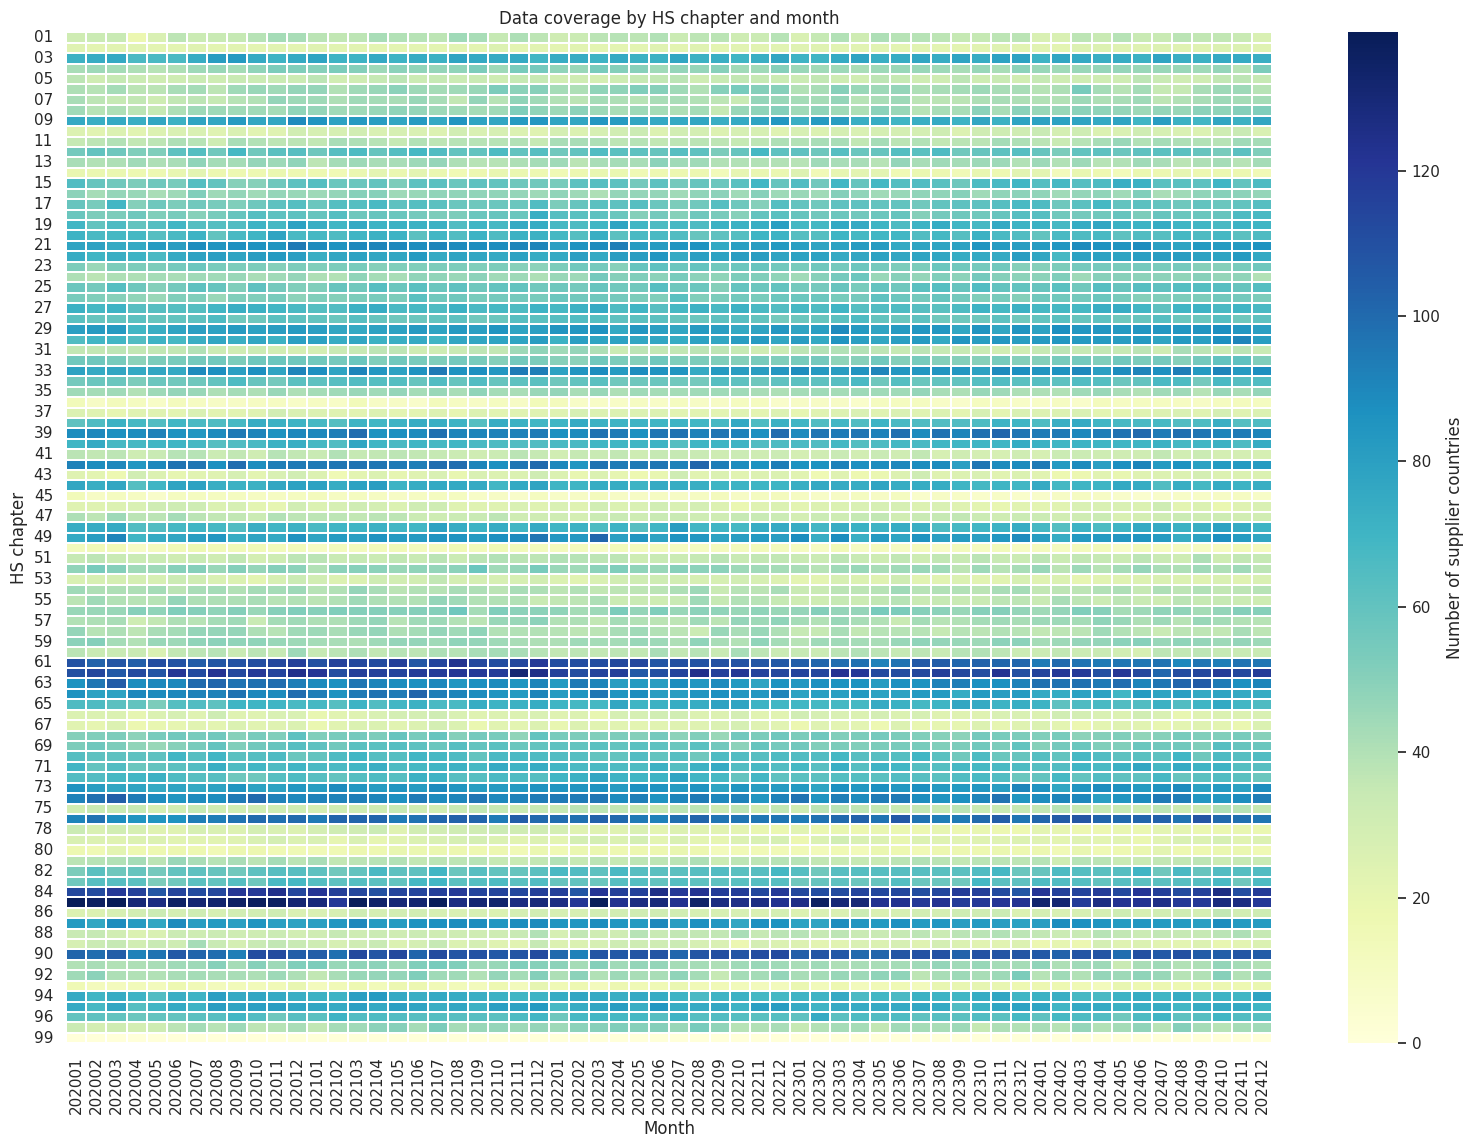

saved figure: figures_production/01a_chapter_coverage_heatmap.png bytes= 133005


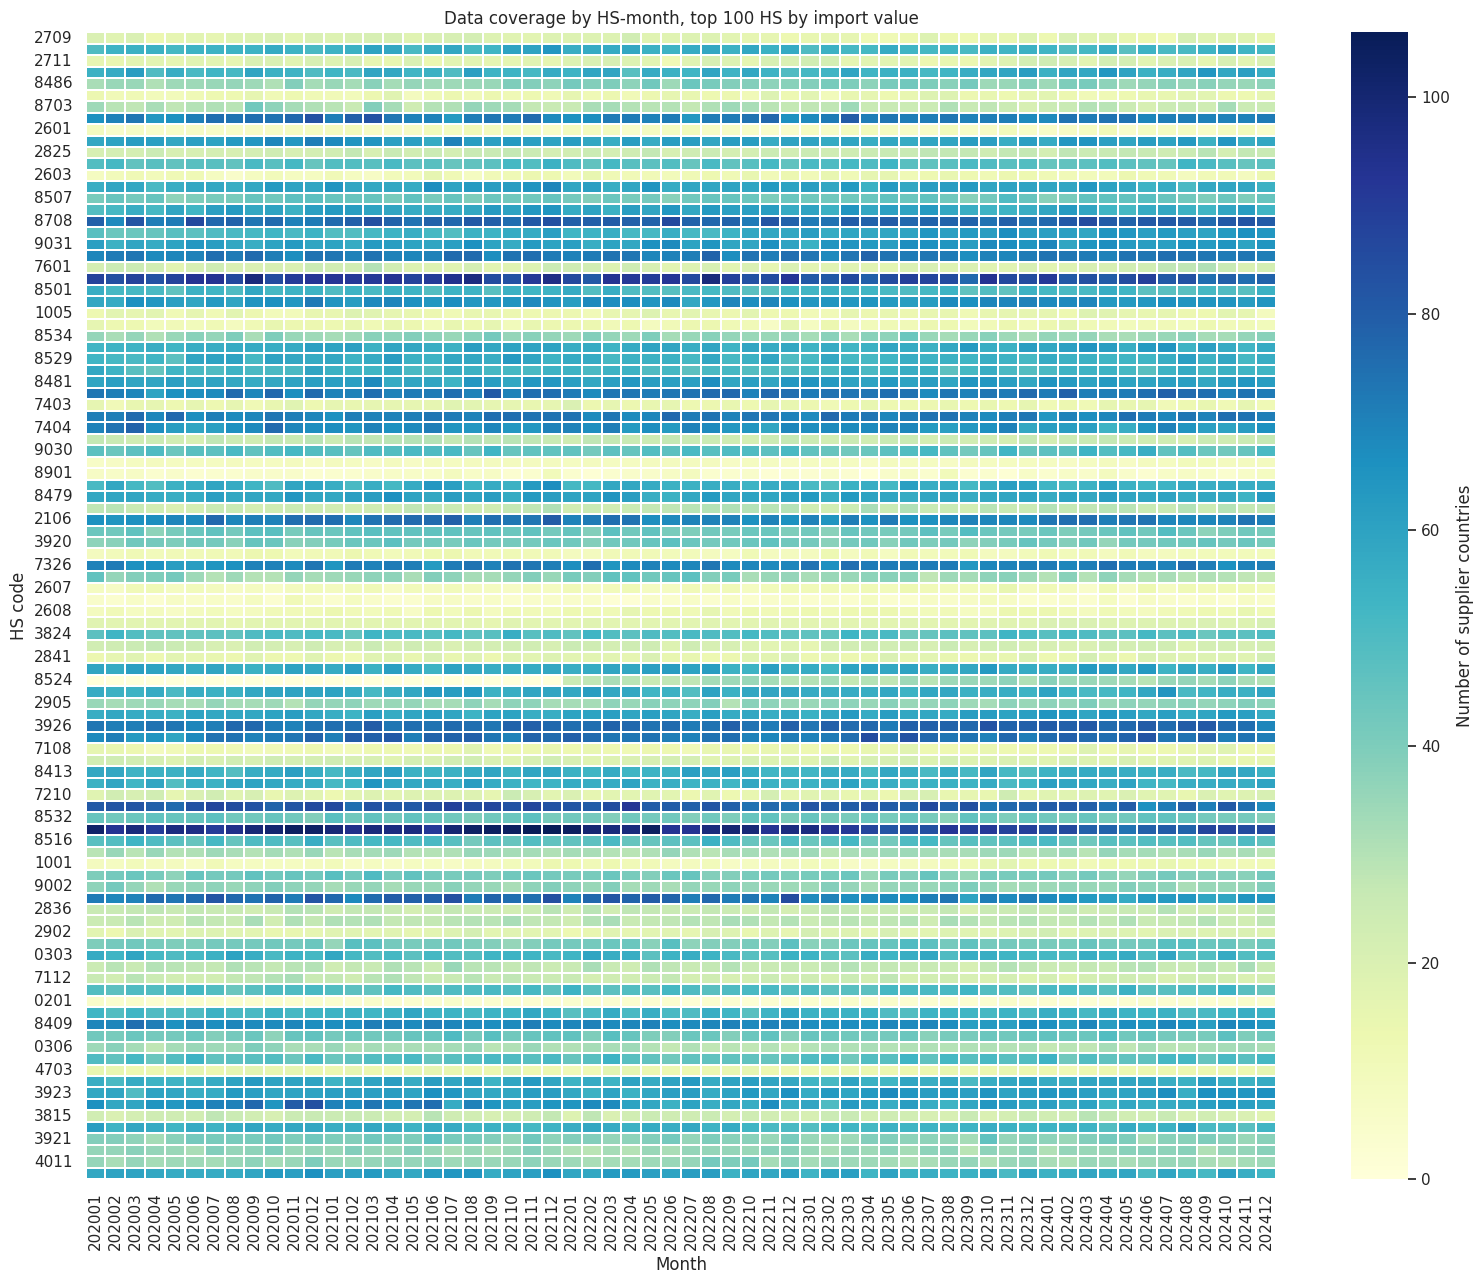

saved figure: figures_production/01b_top100_hs_coverage_heatmap.png bytes= 178110


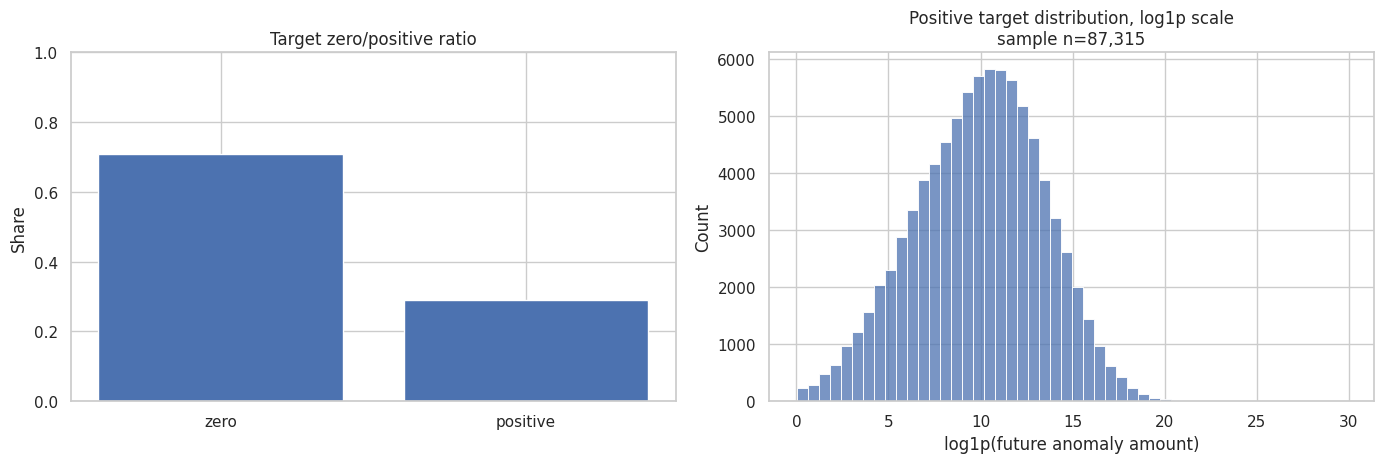

saved figure: figures_production/02_target_distribution.png bytes= 57939


,future_net_anomaly_amount
count,1.106159e+06
mean,5.379584e+08
std,5.035751e+11
min,0.000000e+00
50%,0.000000e+00
75%,3.789325e+02
90%,9.438463e+04
95%,5.527990e+05
99%,7.943168e+06
max,5.279102e+14


In [ ]:
# Cell 7. Safe visual diagnostics

def quick_data_check(df):
    print("Data shape:", df.shape)
    print("Date range:", df["date"].min(), "to", df["date"].max())
    print("Number of months:", df["date"].nunique())
    print("Unique HS codes:", df["hs_code"].nunique())
    print("Unique HS chapters:", df["hs_code"].astype(str).str.zfill(4).str[:2].nunique())
    print("Unique countries:", df["country_code"].nunique())
    y = df["future_net_anomaly_amount"]
    print("Missing target ratio:", y.isna().mean())
    print("Zero target ratio:", (y == 0).mean())
    print("Positive target ratio:", (y > 0).mean())


def plot_chapter_coverage_heatmap(df):
    plot_df = df.copy()
    plot_df["hs_chapter"] = plot_df["hs_code"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(4).str[:2]
    coverage = plot_df.pivot_table(index="hs_chapter", columns="year_month", values="country_code", aggfunc="nunique", fill_value=0)
    coverage = coverage.sort_index()
    plt.figure(figsize=(16, max(8, 0.12 * coverage.shape[0])))
    sns.heatmap(coverage, cmap="YlGnBu", linewidths=0.15, linecolor="white", cbar_kws={"label": "Number of supplier countries"})
    plt.title("Data coverage by HS chapter and month")
    plt.xlabel("Month")
    plt.ylabel("HS chapter")
    save_fig("figures_production/01a_chapter_coverage_heatmap.png")


def plot_top_hs_coverage_heatmap(df, top_n=100):
    top_hs = df.groupby("hs_code")["import_value"].sum().sort_values(ascending=False).head(top_n).index
    plot_df = df[df["hs_code"].isin(top_hs)].copy()
    coverage = plot_df.pivot_table(index="hs_code", columns="year_month", values="country_code", aggfunc="nunique", fill_value=0)
    ordered_hs = [h for h in top_hs if h in coverage.index]
    coverage = coverage.loc[ordered_hs]
    plt.figure(figsize=(16, max(8, 0.13 * coverage.shape[0])))
    sns.heatmap(coverage, cmap="YlGnBu", linewidths=0.1, linecolor="white", cbar_kws={"label": "Number of supplier countries"})
    plt.title(f"Data coverage by HS-month, top {top_n} HS by import value")
    plt.xlabel("Month")
    plt.ylabel("HS code")
    save_fig(f"figures_production/01b_top{top_n}_hs_coverage_heatmap.png")


def plot_target_distribution(df, sample_n=300000):
    y = df["future_net_anomaly_amount"].dropna()
    y_plot = y.sample(sample_n, random_state=RANDOM_STATE) if len(y) > sample_n else y
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    axes[0].bar(["zero", "positive"], [(y == 0).mean(), (y > 0).mean()])
    axes[0].set_title("Target zero/positive ratio")
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel("Share")
    pos = y_plot[y_plot > 0]
    if len(pos) > 0:
        sns.histplot(np.log1p(pos), bins=50, ax=axes[1])
        axes[1].set_title(f"Positive target distribution, log1p scale\nsample n={len(pos):,}")
    axes[1].set_xlabel("log1p(future anomaly amount)")
    save_fig("figures_production/02_target_distribution.png")

quick_data_check(crane)
plot_chapter_coverage_heatmap(crane)
plot_top_hs_coverage_heatmap(crane, top_n=100)
plot_target_distribution(crane, sample_n=300000)

display(crane["future_net_anomaly_amount"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

HS-month panel: (67372, 7)


,hs_code,date,Z_ht,hs_import_value,n_country,mean_abs_rel_z,max_abs_rel_z
0,0101,2020-01-01,0.782162,787736,6,1.119444,2.331869
1,0101,2020-03-01,1.949373,4754947,4,1.109198,2.240398
2,0101,2020-04-01,1.569024,1730909,4,1.003489,1.828965
3,0101,2020-05-01,5.832146,2523463,3,10.969735,31.909205
4,0101,2020-07-01,1.274254,1334986,4,1.733045,4.549382


Selected HS nodes: 120


,hs_code,n_month,total_import,mean_Z
242,2709,60,388924477700,0.952461
1062,8542,60,265194879985,1.043423
244,2711,60,182381188096,0.689981
243,2710,60,110320867308,0.581579
1020,8486,60,93835722545,1.035292
236,2701,60,88667475717,0.697549
1076,8703,60,65652543941,1.197428
1038,8517,60,58703128127,0.740962
218,2601,60,44262849279,1.115782
1005,8471,60,42672741406,0.886357


Raw Z matrix shape: (60, 120)


hs_code,2709,8542,2711,2710,8486,2701,8703,8517,2601,8471,2825,8541,2603,8473,8507,3004,8708,3002,9031,8544,7601,4202,8501,8504,1005,7208,8534,8414,8529,8523,8481,9018,7403,8536,7404,3818,9030,0202,8901,9027,8479,8411,2106,8528,3920,7110,7326,7204,2607,8802,2608,0203,3824,7202,2841,8421,8524,8543,2905,8537,3926,7602,7108,7219,8413,9401,7210,6204,8532,6110,8516,2933,1001,9001,9002,6403,2836,7308,2902,3907,0303,7606,7112,8483,9032,8409,8443,0306,8419,4703,9506,0201,3923,6404,3815,9403,3921,9013,4011,0901,8431,0307,6202,2901,6203,2804,8538,6109,7113,8482,8525,2844,8518,7410,3304,1701,9021,3204,6402,9026
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-01-01,1.390092,1.143813,0.522154,0.507080,0.645665,0.686871,1.077579,0.589257,0.792274,0.969647,0.948190,1.864903,0.573162,1.429298,0.156200,0.886124,0.852734,1.162216,0.907030,1.019030,0.524189,2.005053,1.118114,1.301593,1.009247,4.024516,1.024548,1.340560,0.793261,0.810280,1.239718,0.658821,0.623648,1.164858,1.251693,1.164625,0.803380,2.227449,0.991392,0.783447,0.727361,0.920515,1.165444,1.637746,0.946165,0.735690,0.497278,0.913634,6.488953,109.730197,0.934330,0.819649,1.132632,1.674258,0.591275,0.870394,NaN,1.272976,1.338795,0.972500,1.027129,1.187741,0.792869,1.082713,1.433295,1.865296,1.331425,2.968852,1.422275,2.995594,1.505950,0.467663,0.344544,0.723891,2.790937,1.432656,1.447833,1.731714,0.959300,0.865661,0.936894,1.079065,3.295930,0.995826,0.746926,0.757248,2.240754,1.159547,1.151327,0.930945,1.696427,0.095816,0.294862,1.933781,0.638809,1.406567,0.879652,0.918263,1.386470,1.200526,1.247165,1.156153,3.178021,0.747039,2.647042,0.783872,1.138583,1.565206,1.375944,1.581306,0.676660,1.111015,1.820243,1.377686,0.666915,1.918177,0.757280,2.185154,1.281561,1.018345
2020-02-01,0.886108,1.128202,0.665680,0.641504,0.726172,0.694168,1.261251,0.484337,1.844635,0.618979,0.284812,2.260413,0.990750,1.632534,0.181347,0.979362,0.979528,0.921403,1.066214,1.091285,0.586355,1.881152,1.149289,0.904258,0.984346,1.435304,1.073778,0.907374,0.913540,0.965115,0.847315,0.528032,1.082181,0.916849,1.035385,0.864995,1.049406,0.776707,1.014465,1.111097,0.656659,0.412876,1.069587,1.849701,1.082211,1.052127,0.818851,0.716543,3.581829,1.467443,0.916216,0.587994,0.885176,1.412914,0.149777,0.950835,NaN,1.431198,1.141274,1.081597,1.209643,1.123520,1.093991,1.079106,1.285210,2.142432,1.663690,2.059756,1.532546,1.902279,1.696555,0.494793,0.324719,1.045968,2.561829,1.042667,1.733805,1.125949,0.906294,0.683276,1.174090,1.368813,1.068597,0.872414,0.976257,0.740355,1.860748,0.756327,0.899199,0.909624,1.841000,0.285055,0.691317,1.945355,1.103708,1.073907,0.916150,0.665120,0.921754,1.301355,1.555199,1.306547,2.135910,0.777708,1.351255,1.240319,0.945627,1.604250,0.976779,1.410666,0.689088,1.093777,1.276649,1.032495,0.454712,1.232201,0.758639,1.232815,1.116845,1.009414
2020-03-01,0.751822,1.158706,0.718654,0.487614,0.913805,0.828244,1.205709,0.616225,1.638099,0.554649,0.502520,2.088106,4.873012,2.850833,0.495786,0.892339,1.016442,0.961292,1.006973,1.275898,0.340250,1.730475,0.972888,1.485455,0.959242,0.991407,1.040901,1.201063,0.816523,0.506444,1.049428,0.918895,0.914040,1.280603,1.017850,1.141376,0.896369,2.509008,1.027780,0.848419,0.781463,0.595595,1.140278,2.307386,1.282042,1.613822,0.517023,0.476980,1.246192,0.716118,1.216452,0.622093,1.027354,1.572012,0.412505,1.077860,NaN,1.509006,1.255120,0.961231,1.126709,1.150916,0.987971,0.984770,1.330411,1.807426,1.784178,2.447173,1.325197,2.338963,1.780111,0.560550,0.283505,1.117492,2.114710,1.089578,1.154979,1.976413,1.314455,0.783577,1.394963,1.035530,0.902578,1.199065,0.699041,0.876169,1.729813,1.521066,0.799679,1.249306,1.567154,0.016109,0.465126,2.567393,0.626985,1.249458,0.804737,0.565932,1.819951,1.588470,1.751747,1.075329,2.620293,0.948162,1.821071,1.955130,1.098111,1.287989,1.103979,1.545898,0.844048,0.891826,2.127402,1.320694,0.485794,2.042910,0.968857,2.008068,1.453297,0.936768
2020-04

Final standardized Z matrix: (60, 120)


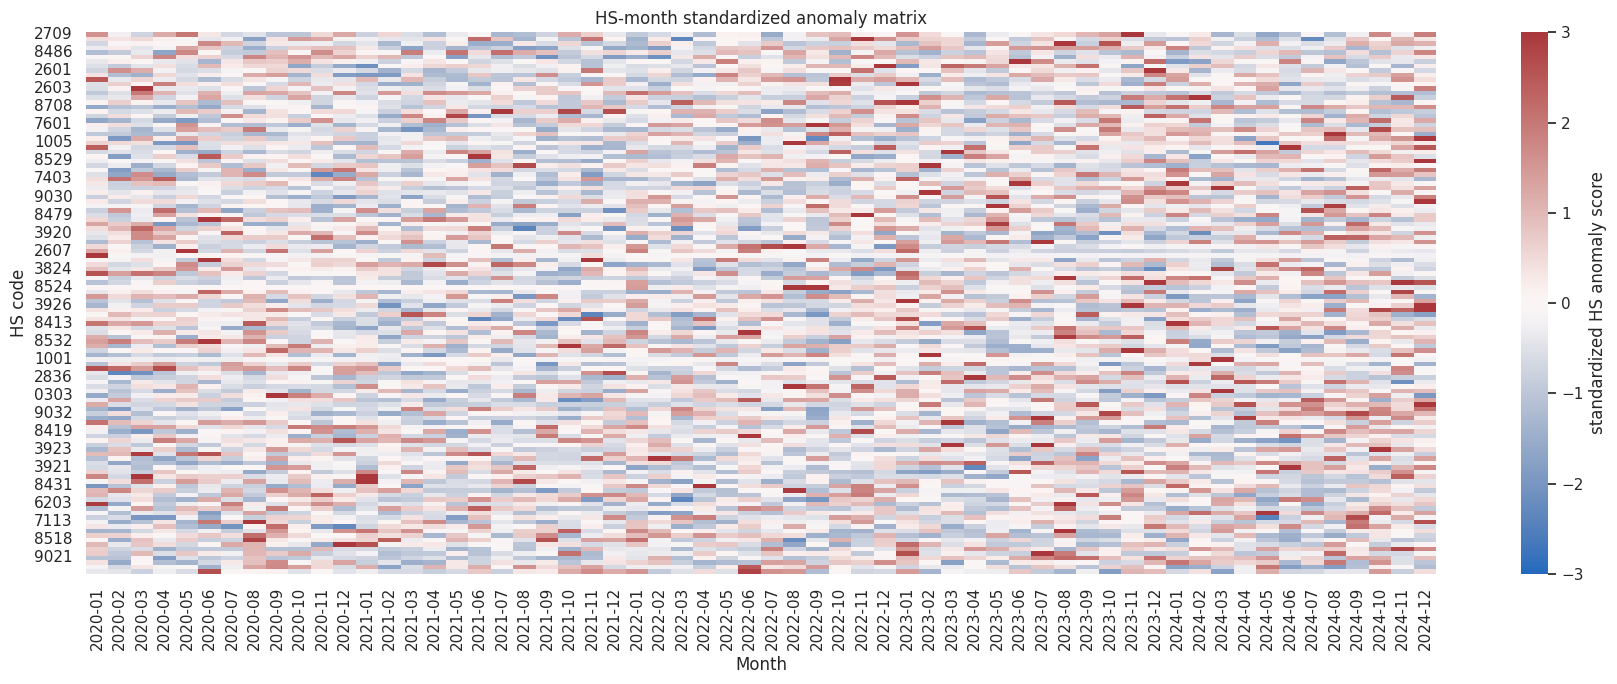

saved figure: figures_factor_graphical/04_hs_month_standardized_anomaly_matrix_clean.png bytes= 145140


In [19]:
# Cell 8. Build HS-month anomaly matrix for Factor + Graphical model

def build_hs_month_panel(df, agg_method=HS_AGG_METHOD):
    tmp = df.copy().dropna(subset=["rel_z", "date", "hs_code", "import_value"])
    tmp["abs_rel_z"] = tmp["rel_z"].abs()
    tmp["total_hs_month_import"] = tmp.groupby(["hs_code", "date"])["import_value"].transform("sum")
    tmp["value_weight"] = tmp["import_value"] / tmp["total_hs_month_import"]

    if agg_method == "value_weighted_abs":
        tmp["z_component"] = tmp["value_weight"] * tmp["abs_rel_z"]
    elif agg_method == "value_weighted_signed":
        tmp["z_component"] = tmp["value_weight"] * tmp["rel_z"]
    elif agg_method == "simple_abs":
        tmp["z_component"] = tmp["abs_rel_z"]
    elif agg_method == "simple_signed":
        tmp["z_component"] = tmp["rel_z"]
    else:
        raise ValueError("Invalid HS_AGG_METHOD")

    agg_func = "sum" if agg_method.startswith("value_weighted") else "mean"

    hs_month = tmp.groupby(["hs_code", "date"], as_index=False).agg(
        Z_ht=("z_component", agg_func),
        hs_import_value=("import_value", "sum"),
        n_country=("country_code", "nunique"),
        mean_abs_rel_z=("abs_rel_z", "mean"),
        max_abs_rel_z=("abs_rel_z", "max"),
    )
    return hs_month.sort_values(["hs_code", "date"]).reset_index(drop=True)


hs_month = build_hs_month_panel(crane)
print("HS-month panel:", hs_month.shape)
display(hs_month.head())

coverage = (
    hs_month.groupby("hs_code")
    .agg(
        n_month=("date", "nunique"),
        total_import=("hs_import_value", "sum"),
        mean_Z=("Z_ht", "mean"),
    )
    .reset_index()
)

eligible = (
    coverage[coverage["n_month"] >= MIN_MONTH_COVERAGE]
    .sort_values("total_import", ascending=False)
    .head(MAX_HS_NODES)
)

selected_hs = eligible["hs_code"].astype(str).tolist()
hs_month_sel = hs_month[hs_month["hs_code"].astype(str).isin(selected_hs)].copy()

print(f"Selected HS nodes: {len(selected_hs)}")
display(eligible.head(20))

Z_mat_raw = (
    hs_month_sel.pivot_table(
        index="date",
        columns="hs_code",
        values="Z_ht",
        aggfunc="mean"
    )
    .sort_index()
)

Z_mat_raw = Z_mat_raw[selected_hs]
print("Raw Z matrix shape:", Z_mat_raw.shape)
display(Z_mat_raw.head())

Z_std, Z_mu, Z_sd = safe_zscore_matrix(Z_mat_raw)

if FILL_MISSING_METHOD == "zero_after_standardize":
    Z_mat = Z_std.fillna(0.0)
elif FILL_MISSING_METHOD == "hs_mean":
    Z_mat = Z_mat_raw.apply(lambda x: x.fillna(x.mean()), axis=0)
    Z_mat, _, _ = safe_zscore_matrix(Z_mat)
    Z_mat = Z_mat.fillna(0.0)
elif FILL_MISSING_METHOD == "interpolate":
    Z_mat = Z_mat_raw.interpolate(limit_direction="both")
    Z_mat, _, _ = safe_zscore_matrix(Z_mat)
    Z_mat = Z_mat.fillna(0.0)
else:
    raise ValueError("Invalid FILL_MISSING_METHOD")

print("Final standardized Z matrix:", Z_mat.shape)

# -----------------------------
# Clean heatmap for presentation
# -----------------------------
Z_plot = Z_mat.copy()
Z_plot.index = pd.to_datetime(Z_plot.index).strftime("%Y-%m")

plt.figure(figsize=(18, 7))
sns.heatmap(
    Z_plot.T,
    cmap="vlag",
    center=0,
    vmin=-3,
    vmax=3,
    cbar_kws={"label": "standardized HS anomaly score"}
)
plt.title("HS-month standardized anomaly matrix")
plt.xlabel("Month")
plt.ylabel("HS code")
plt.xticks(rotation=90)
save_fig("figures_factor_graphical/04_hs_month_standardized_anomaly_matrix_clean.png")


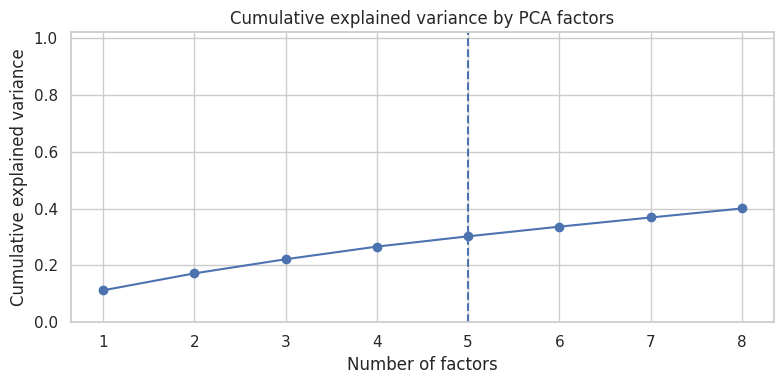

saved figure: figures_factor_graphical/05_pca_cumulative_explained_variance.png bytes= 44336


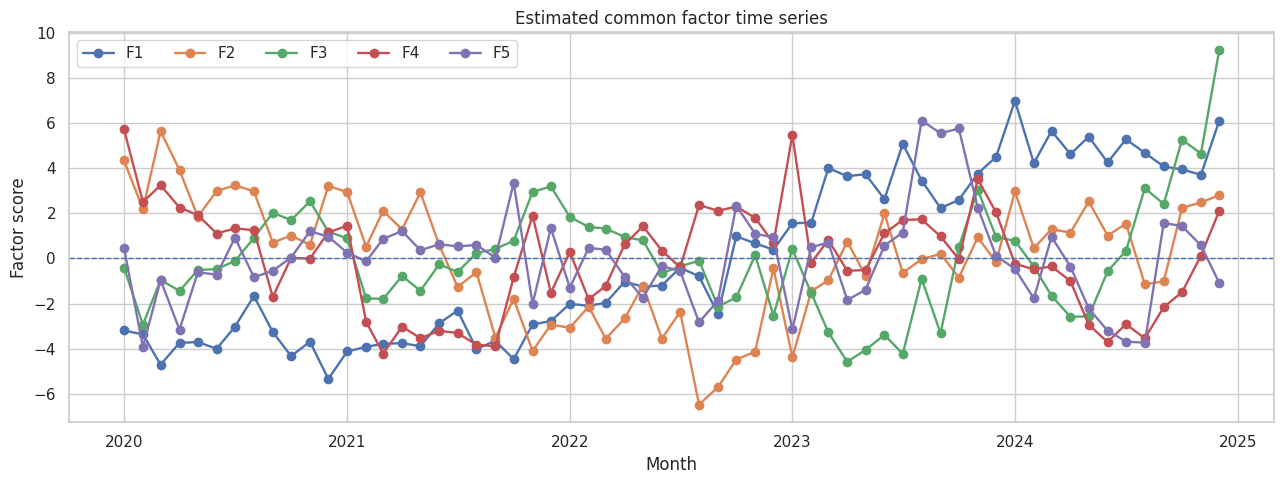

saved figure: figures_factor_graphical/06_common_factor_time_series.png bytes= 244290


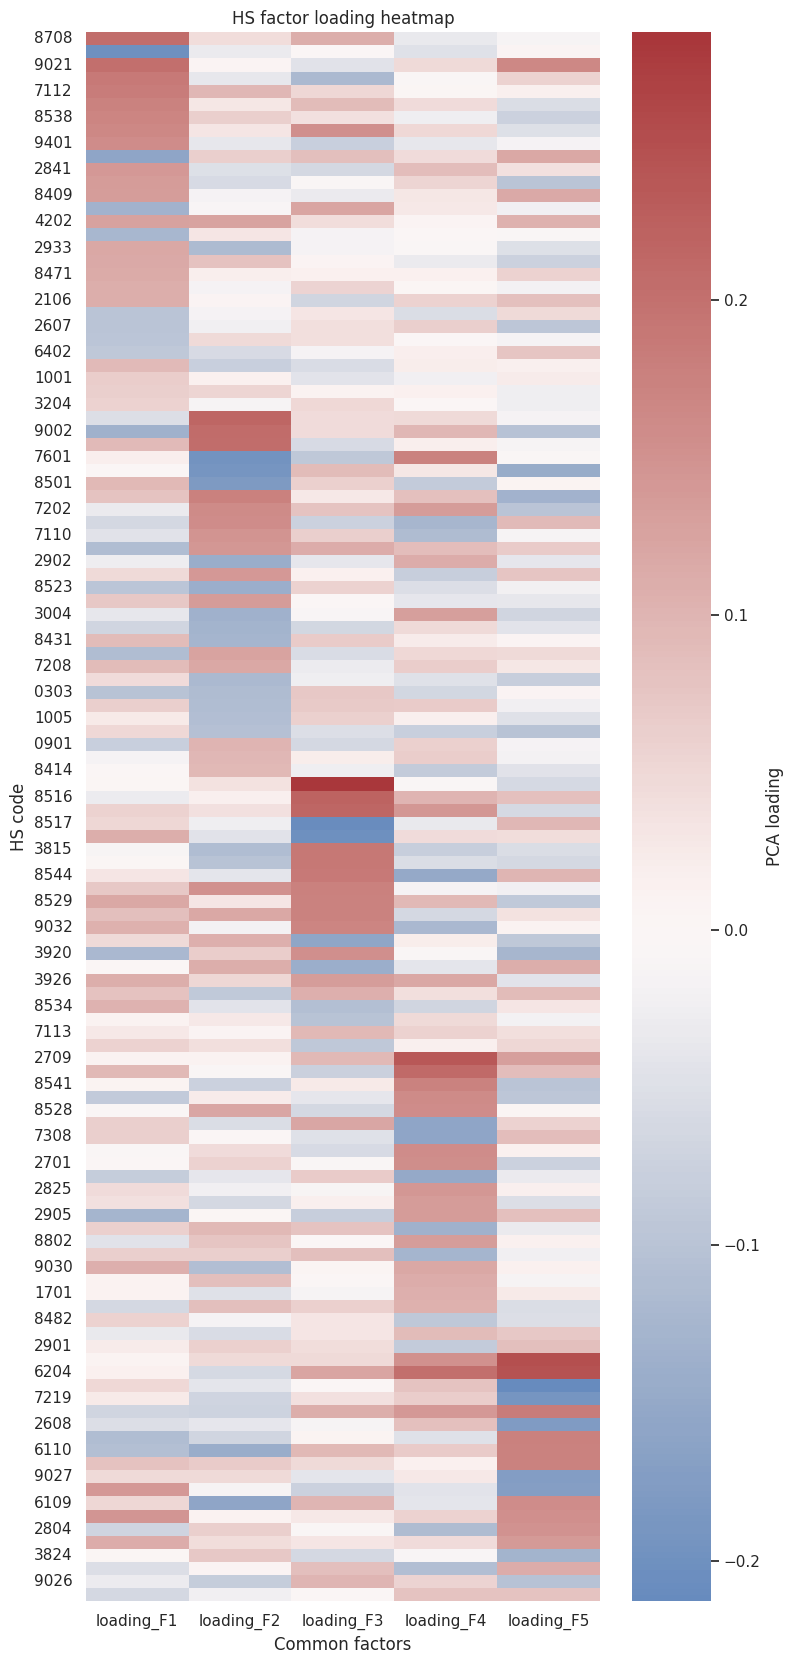

saved figure: figures_factor_graphical/07_factor_loading_heatmap.png bytes= 141623
Factor scores: (60, 5)
Loadings: (120, 6)
Residual matrix: (60, 120)


,F1,F2,F3,F4,F5
date,,,,,
2020-01-01,-3.192566,4.349160,-0.404427,5.729682,0.468991
2020-02-01,-3.372401,2.186011,-2.937811,2.501375,-3.931493
2020-03-01,-4.709235,5.641979,-0.952902,3.248222,-0.957349
2020-04-01,-3.744860,3.923159,-1.441549,2.258280,-3.160716
2020-05-01,-3.708062,1.848576,-0.513603,1.926260,-0.615767


,hs_code,loading_F1,loading_F2,loading_F3,loading_F4,loading_F5
0,2709,0.012249,0.012023,0.095611,0.236968,0.131628
1,8542,-0.034039,-0.057266,0.033315,0.090244,0.071899
2,2711,0.081442,0.068432,0.049275,0.014672,0.173836
3,2710,0.093231,-0.006029,-0.074917,0.209235,0.087955
4,8486,-0.083412,-0.038073,0.068210,-0.149841,-0.030854


In [ ]:
# Cell 9. PCA Factor model and visualizations
max_pca = min(MAX_FACTORS_TO_PLOT, Z_mat.shape[0] - 1, Z_mat.shape[1])
pca_diag = PCA(n_components=max_pca, random_state=RANDOM_STATE)
pca_diag.fit(Z_mat.values)
explained = pca_diag.explained_variance_ratio_

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(explained) + 1), np.cumsum(explained), marker="o")
plt.axvline(N_FACTORS, linestyle="--")
plt.title("Cumulative explained variance by PCA factors")
plt.xlabel("Number of factors")
plt.ylabel("Cumulative explained variance")
plt.ylim(0, 1.02)
save_fig("figures_factor_graphical/05_pca_cumulative_explained_variance.png")

n_factors = min(N_FACTORS, Z_mat.shape[0] - 1, Z_mat.shape[1])
pca = PCA(n_components=n_factors, random_state=RANDOM_STATE)
F = pca.fit_transform(Z_mat.values)
loadings = pca.components_.T
Z_hat = pca.inverse_transform(F)
U = Z_mat.values - Z_hat

factor_scores = pd.DataFrame(F, index=Z_mat.index, columns=[f"F{k+1}" for k in range(n_factors)])
loading_df = pd.DataFrame(loadings, index=Z_mat.columns, columns=[f"loading_F{k+1}" for k in range(n_factors)]).reset_index().rename(columns={"index": "hs_code"})
if "hs_code" not in loading_df.columns:
    loading_df = loading_df.rename(columns={loading_df.columns[0]: "hs_code"})
residual_mat = pd.DataFrame(U, index=Z_mat.index, columns=Z_mat.columns)

factor_scores.to_csv("output_factor_graphical/factor_scores.csv", encoding="utf-8-sig")
loading_df.to_csv("output_factor_graphical/factor_loadings.csv", index=False, encoding="utf-8-sig")
residual_mat.to_csv("output_factor_graphical/hs_idiosyncratic_residual_matrix.csv", encoding="utf-8-sig")

plt.figure(figsize=(13, 5))
for col in factor_scores.columns:
    plt.plot(factor_scores.index, factor_scores[col], marker="o", linewidth=1.7, label=col)
plt.axhline(0, linewidth=1, linestyle="--")
plt.title("Estimated common factor time series")
plt.xlabel("Month")
plt.ylabel("Factor score")
plt.legend(ncol=min(n_factors, 5))
save_fig("figures_factor_graphical/06_common_factor_time_series.png")

loading_heat = loading_df.set_index("hs_code")[[f"loading_F{k+1}" for k in range(n_factors)]]
loading_heat["dominant_factor"] = loading_heat.abs().idxmax(axis=1)
loading_heat["max_abs_loading"] = loading_heat.drop(columns="dominant_factor").abs().max(axis=1)
loading_heat_sorted = loading_heat.sort_values(["dominant_factor", "max_abs_loading"], ascending=[True, False]).drop(columns=["dominant_factor", "max_abs_loading"])
plt.figure(figsize=(8, max(7, 0.14 * len(loading_heat_sorted))))
sns.heatmap(loading_heat_sorted, cmap="vlag", center=0, cbar_kws={"label": "PCA loading"})
plt.title("HS factor loading heatmap")
plt.xlabel("Common factors")
plt.ylabel("HS code")
save_fig("figures_factor_graphical/07_factor_loading_heatmap.png")

print("Factor scores:", factor_scores.shape)
print("Loadings:", loading_df.shape)
print("Residual matrix:", residual_mat.shape)
display(factor_scores.head())
display(loading_df.head())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 30, Apr, 2026
Time:                     02:55:50
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                    6.60113
Nobs:                     58.0000    HQIC:                   5.40833
Log likelihood:          -491.263    FPE:                    106.751
AIC:                      4.64726    Det(Omega_mle):         44.7990
--------------------------------------------------------------------
Results for equation F1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.255122         0.148847            1.714           0.087
L1.F1         0.556823         0.129704            4.293           0.000
L1.F2         0.106054         0.088344            1.200           0.230
L1.F3        -0.128923

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


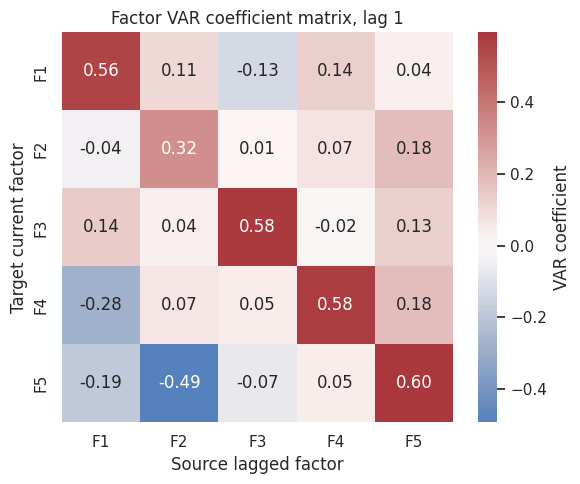

saved figure: figures_factor_graphical/09_factor_var_coefficients_lag_1.png bytes= 67735


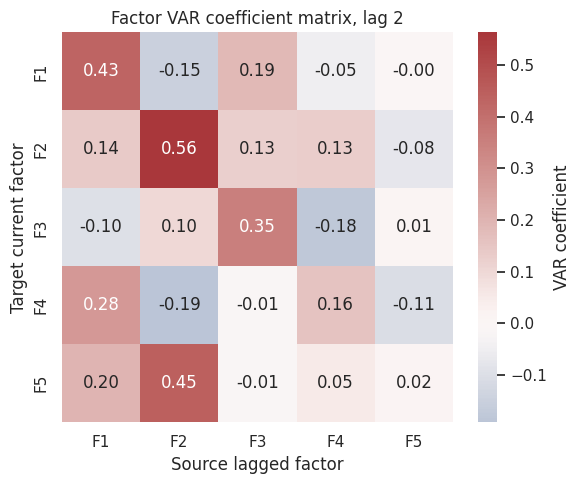

saved figure: figures_factor_graphical/09_factor_var_coefficients_lag_2.png bytes= 67509


In [ ]:
# Cell 10. Factor VAR
F_for_var = factor_scores.copy().dropna()
if len(F_for_var) > (n_factors * VAR_MAX_LAG + 5):
    var_model = VAR(F_for_var)
    if VAR_SELECTED_LAG is None:
        lag_order_results = var_model.select_order(maxlags=min(VAR_MAX_LAG, max(1, len(F_for_var)//5)))
        selected_lag = int(lag_order_results.aic) if not np.isnan(lag_order_results.aic) else 1
        selected_lag = max(1, min(selected_lag, VAR_MAX_LAG))
    else:
        selected_lag = VAR_SELECTED_LAG
    var_res = var_model.fit(selected_lag)
    print(var_res.summary())

    var_coef_rows = []
    for lag in range(selected_lag):
        A = pd.DataFrame(var_res.coefs[lag], index=factor_scores.columns, columns=factor_scores.columns)
        A.to_csv(f"output_factor_graphical/factor_var_A_lag_{lag+1}.csv", encoding="utf-8-sig")
        plt.figure(figsize=(6, 5))
        sns.heatmap(A, cmap="vlag", center=0, annot=True, fmt=".2f", cbar_kws={"label": "VAR coefficient"})
        plt.title(f"Factor VAR coefficient matrix, lag {lag+1}")
        plt.xlabel("Source lagged factor")
        plt.ylabel("Target current factor")
        save_fig(f"figures_factor_graphical/09_factor_var_coefficients_lag_{lag+1}.png")
        for target in factor_scores.columns:
            for source in factor_scores.columns:
                var_coef_rows.append({"lag": lag+1, "source_factor": source, "target_factor": target, "coef": A.loc[target, source], "abs_coef": abs(A.loc[target, source])})
    var_coef_df = pd.DataFrame(var_coef_rows)
    var_coef_df.to_csv("output_factor_graphical/factor_var_coefficients_long.csv", index=False, encoding="utf-8-sig")
else:
    var_res = None
    var_coef_df = pd.DataFrame()
    print("Not enough observations for factor VAR. Skipped.")

Selected Graphical LASSO alpha: 0.41828551879207737
Edges with nonzero partial corr: 16


,hs_i,hs_j,omega_ij,partial_corr,abs_partial_corr,sign
8,7404,1001,-0.267144,0.244420,0.244420,positive
14,1001,3907,-0.135849,0.127141,0.127141,positive
7,8523,3818,-0.114120,0.110839,0.110839,positive
12,2905,2933,-0.090932,0.088713,0.088713,positive
11,8524,2902,-0.074900,0.073243,0.073243,positive
0,8542,8528,-0.053381,0.052347,0.052347,positive
15,8443,0201,-0.051169,0.050189,0.050189,positive
1,2711,8543,-0.045979,0.045121,0.045121,positive
6,7208,7112,-0.027187,0.026714,0.026714,positive
10,8421,0306,-0.020272,0.019926,0.019926,positive


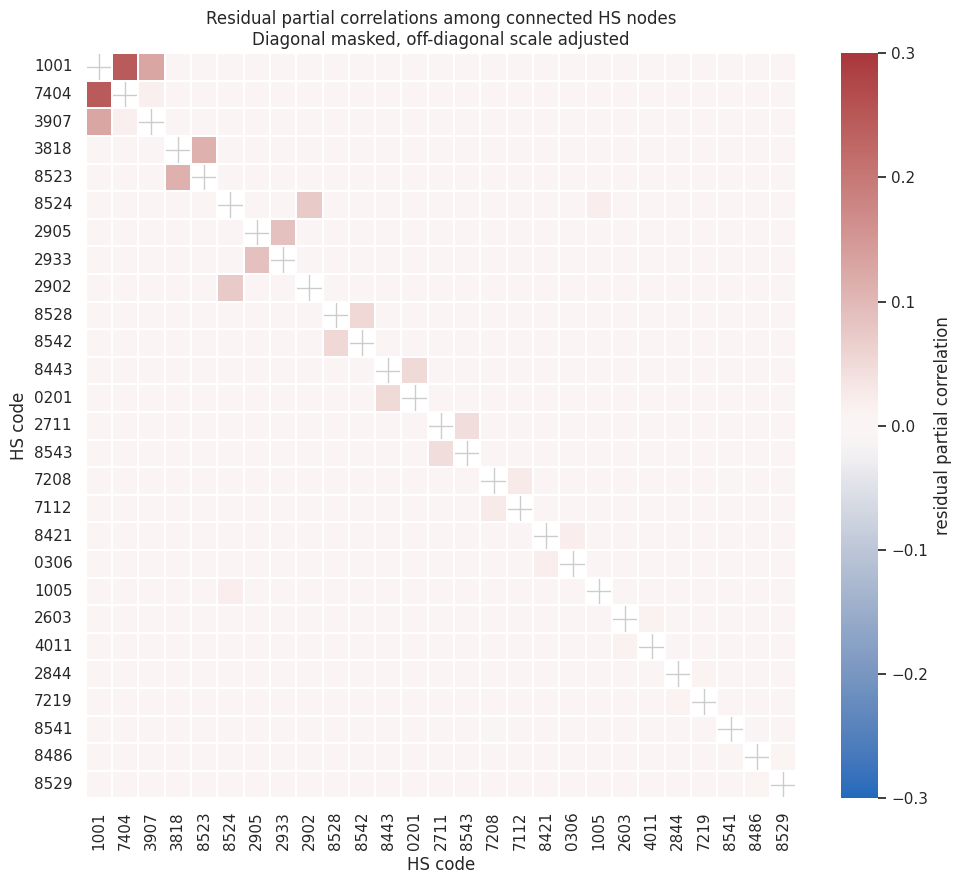

In [21]:
# Cell 11. Residual Graphical LASSO
U_std, U_mu, U_sd = safe_zscore_matrix(residual_mat)
U_std = U_std.fillna(0.0)

gl_cv = GraphicalLassoCV(alphas=8, cv=min(5, max(2, len(U_std)//12)), max_iter=1000)
gl_cv.fit(U_std.values)
precision = gl_cv.precision_
alpha_selected = gl_cv.alpha_
print("Selected Graphical LASSO alpha:", alpha_selected)

hs_codes_graph = list(U_std.columns)
precision_df = pd.DataFrame(precision, index=hs_codes_graph, columns=hs_codes_graph)
precision_df.to_csv("output_factor_graphical/residual_precision_matrix_graphical_lasso.csv", encoding="utf-8-sig")

diag = np.sqrt(np.diag(precision))
partial_corr = -precision / np.outer(diag, diag)
np.fill_diagonal(partial_corr, 1.0)
partial_corr_df = pd.DataFrame(partial_corr, index=hs_codes_graph, columns=hs_codes_graph)
partial_corr_df.to_csv("output_factor_graphical/residual_partial_correlation_matrix.csv", encoding="utf-8-sig")

edge_rows = []
p = len(hs_codes_graph)
for i in range(p):
    for j in range(i + 1, p):
        pc = partial_corr[i, j]
        om = precision[i, j]
        if abs(pc) > 1e-12:
            edge_rows.append({"hs_i": hs_codes_graph[i], "hs_j": hs_codes_graph[j], "omega_ij": om, "partial_corr": pc, "abs_partial_corr": abs(pc), "sign": "positive" if pc > 0 else "negative"})
edge_df = pd.DataFrame(edge_rows).sort_values("abs_partial_corr", ascending=False)
edge_df.to_csv("output_factor_graphical/residual_graphical_lasso_edges_all.csv", index=False, encoding="utf-8-sig")
print("Edges with nonzero partial corr:", len(edge_df))
display(edge_df.head(20))

top_connected = (
    edge_df.assign(weight=edge_df["abs_partial_corr"])
    .melt(id_vars=["weight"], value_vars=["hs_i", "hs_j"], value_name="hs_code")
    .groupby("hs_code")["weight"].sum().sort_values(ascending=False).head(min(50, len(hs_codes_graph))).index.tolist()
)


heat_pc = partial_corr_df.loc[top_connected, top_connected].copy()

mask = np.eye(len(heat_pc), dtype=bool)

plt.figure(figsize=(10, 9))
sns.heatmap(
    heat_pc,
    mask=mask,
    cmap="vlag",
    center=0,
    vmin=-0.30,
    vmax=0.30,
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "residual partial correlation"}
)

plt.title(
    "Residual partial correlations among connected HS nodes\n"
    "Diagonal masked, off-diagonal scale adjusted"
)
plt.xlabel("HS code")
plt.ylabel("HS code")
plt.tight_layout()
plt.savefig(
    "figures_factor_graphical/11_residual_partial_correlation_heatmap_masked.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

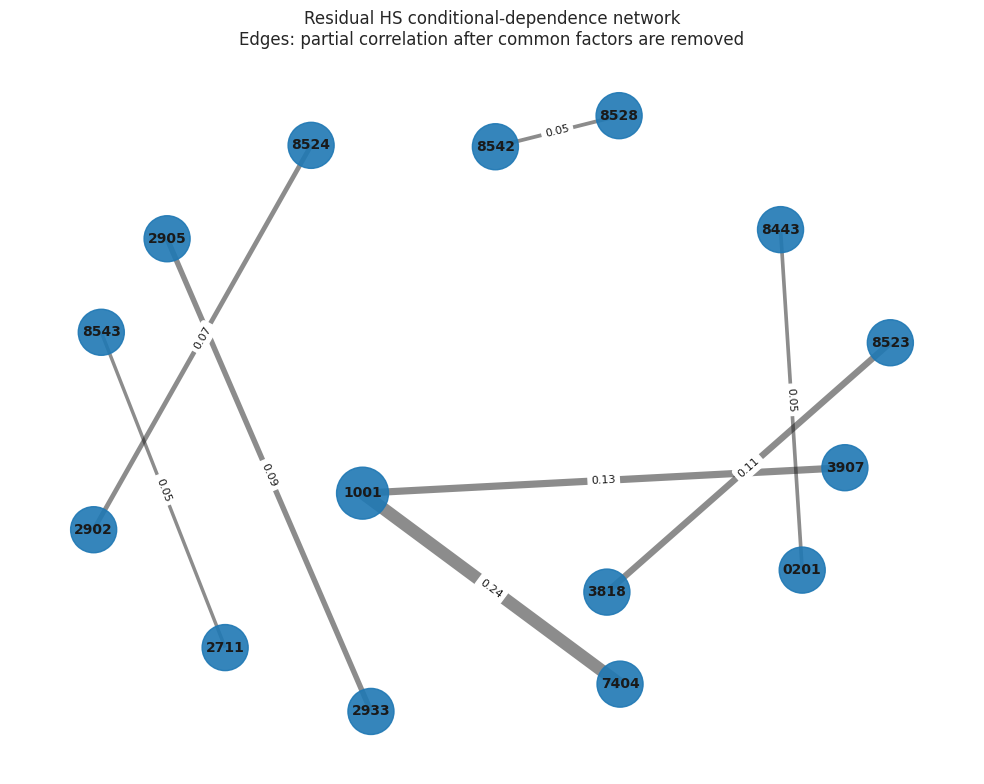

In [22]:
edge_plot = edge_df[edge_df["abs_partial_corr"] >= 0.03].copy()

G_resid = nx.Graph()

for _, r in edge_plot.iterrows():
    G_resid.add_edge(
        r["hs_i"],
        r["hs_j"],
        weight=r["abs_partial_corr"],
        partial_corr=r["partial_corr"],
        sign=r["sign"]
    )

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_resid, seed=123, k=0.8)

weights = [G_resid[u][v]["weight"] for u, v in G_resid.edges()]
max_w = max(weights) if weights else 1

edge_widths = [1 + 8 * w / max_w for w in weights]

node_sizes = [
    800 + 300 * G_resid.degree(n)
    for n in G_resid.nodes()
]

nx.draw_networkx_nodes(
    G_resid,
    pos,
    node_size=node_sizes,
    alpha=0.9
)

nx.draw_networkx_edges(
    G_resid,
    pos,
    width=edge_widths,
    alpha=0.5
)

nx.draw_networkx_labels(
    G_resid,
    pos,
    font_size=10,
    font_weight="bold"
)

edge_labels = {
    (u, v): f"{G_resid[u][v]['partial_corr']:.2f}"
    for u, v in G_resid.edges()
}

nx.draw_networkx_edge_labels(
    G_resid,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("Residual HS conditional-dependence network\nEdges: partial correlation after common factors are removed")
plt.axis("off")
plt.tight_layout()
plt.savefig(
    "figures_factor_graphical/13_residual_hs_network_clean.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# Cell 12. Optional bootstrap edge stability

def block_bootstrap_indices(T, block_size, rng):
    starts = np.arange(0, T - block_size + 1)
    idx = []
    while len(idx) < T:
        s = rng.choice(starts)
        idx.extend(range(s, s + block_size))
    return np.array(idx[:T])

if RUN_BOOTSTRAP_STABILITY:
    rng = np.random.default_rng(RANDOM_STATE)
    T, p = U_std.shape
    edge_count = np.zeros((p, p), dtype=float)
    for b in range(BOOTSTRAP_B):
        idx = block_bootstrap_indices(T, BOOTSTRAP_BLOCK_SIZE, rng)
        Ub = U_std.values[idx, :]
        try:
            gl_b = GraphicalLasso(alpha=alpha_selected, max_iter=1000)
            gl_b.fit(Ub)
            prec_b = gl_b.precision_
            diag_b = np.sqrt(np.diag(prec_b))
            pc_b = -prec_b / np.outer(diag_b, diag_b)
            np.fill_diagonal(pc_b, 0.0)
            selected_b = np.abs(pc_b) >= EDGE_ABS_PARTIAL_CORR_THRESHOLD
            edge_count += selected_b.astype(float)
        except Exception as err:
            print(f"Bootstrap {b} failed: {err}")
    stability = edge_count / BOOTSTRAP_B
    np.fill_diagonal(stability, 0.0)
    stability_df = pd.DataFrame(stability, index=hs_codes_graph, columns=hs_codes_graph)
    stability_df.to_csv("output_factor_graphical/residual_edge_stability_matrix.csv", encoding="utf-8-sig")
    stability_rows = []
    for i in range(p):
        for j in range(i + 1, p):
            stability_rows.append({"hs_i": hs_codes_graph[i], "hs_j": hs_codes_graph[j], "edge_stability": stability[i, j], "partial_corr": partial_corr[i, j], "abs_partial_corr": abs(partial_corr[i, j])})
    stability_edge_df = pd.DataFrame(stability_rows).sort_values(["edge_stability", "abs_partial_corr"], ascending=False)
    stability_edge_df.to_csv("output_factor_graphical/residual_edge_stability_edges.csv", index=False, encoding="utf-8-sig")
    print("Bootstrap stability complete.")
    display(stability_edge_df.head(20))
else:
    stability_df = None
    stability_edge_df = edge_df.copy()
    stability_edge_df["edge_stability"] = np.nan
    print("Bootstrap stability skipped.")

Bootstrap stability skipped.


,hs_code,weighted_degree,betweenness,eigenvector,mean_Z,total_import
72,1001,0.371561,0.000142,0,0.907718,7180844517
34,7404,0.244420,0.000000,0,1.405435,11896904870
79,3907,0.127141,0.000000,0,0.920038,6536868537
29,8523,0.110839,0.000000,0,1.088571,13407404679
35,3818,0.110839,0.000000,0,1.062177,11834796948
58,2905,0.088713,0.000000,0,1.041051,8487400629
71,2933,0.088713,0.000000,0,0.641009,7248269111
56,8524,0.073243,0.000000,0,0.824822,8582557327
78,2902,0.073243,0.000000,0,1.167988,6575635219
1,8542,0.052347,0.000000,0,1.043423,265194879985


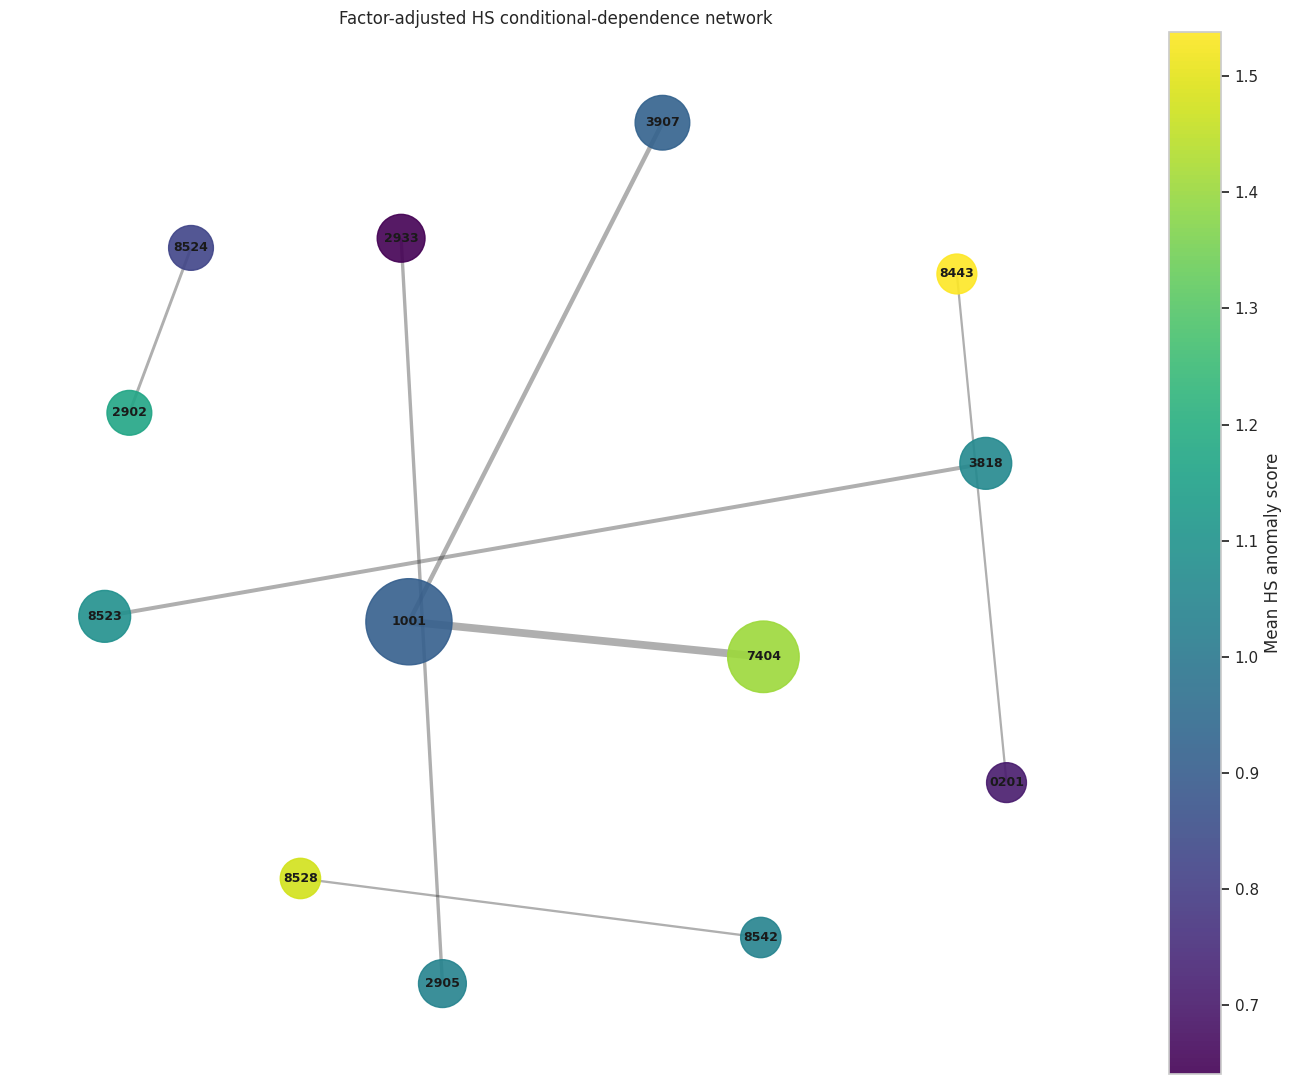

saved figure: figures_factor_graphical/13_factor_adjusted_hs_network.png bytes= 133013
Cell-level data with graph features: (1409337, 76)


,date,hs_code,country_code,country_name,hs_name,import_value,import_weight,year_month,year,month,unit_price,log_price,ht_country_count,ht_median_log_price,ht_mad_log_price,rel_z,price_rank_pct,loo_median_log_price,counterfactual_dev,counterfactual_dev_scaled,network_isolation_score,total_hs_month_import,import_share_country,hhi_hs_month,concentration_risk,lag_date,price_return,rank_shift,abs_rank_shift,import_growth,weight_growth,log_import_value,log_import_weight,abs_rel_z,anomaly_abs,anomaly_up,anomaly_down,anomaly_abs_roll3,anomaly_up_roll3,anomaly_down_roll3,abs_rel_z_roll3,price_return_roll3,price_volatility_roll3,import_growth_roll3,return_sign,majority_sign,sync_score,idiosyncratic_current_score,ht_median_return,ht_mad_return,total_import_return,price_distribution_shift,month_sin,month_cos,next_date,next_rel_z,next_price_rank_pct,next_network_isolation_score,has_next_month,future_abs_anomaly,future_up_anomaly,future_down_anomaly,future_net_anomaly_amount,future_up_anomaly_amount,future_down_anomaly_amount,graph_neighbor_risk,graph_own_residual_abs,graph_factor_exposure,graph_weighted_degree,graph_betweenness,graph_eigenvector,F1,F2,F3,F4,F5
0,2020-06-01,0101,AR,아르헨티나,살아 있는 말ㆍ당나귀ㆍ노새ㆍ버새,244500,4000,202006,2020,6,61.125000,4.112921,2,4.527626,0.414705,NaN,NaN,NaN,NaN,NaN,NaN,664789,0.367786,0.534961,0.196751,NaT,NaN,NaN,NaN,NaN,NaN,12.406971,8.294050,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.500000,NaN,0.086364,0.395163,-0.736557,1.161132,1.224647e-16,-1.000000e+00,2021-03-01,1.973954,1.000000,0.905979,False,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2021-03-01,0101,AR,아르헨티나,살아 있는 말ㆍ당나귀ㆍ노새ㆍ버새,434300,4000,202103,2021,3,108.575000,4.687441,4,4.459710,0.115368,1.973954,1.0,4.456706,0.230736,2.000000,0.905979,1729062,0.251177,0.365315,0.091759,2020-06-01,NaN,NaN,NaN,0.776278,0.000,12.981491,8.294050,1.973954,1.0,1.0,0.0,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.973954,0.926199,0.115368,49.492407,9.028226,1.000000e+00,6.123234e-17,2021-04-01,-1.000000,0.000000,0.763820,True,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2021-04-01,0101,AR,아르헨티나,살아 있는 말ㆍ당나귀ㆍ노새ㆍ버새,266700,4000,202104,2021,4,66.675000,4.199830,3,4.677608,0.477778,-1.000000,0.0,4.978310,-0.778480,-1.629376,0.763820,1086659,0.245431,0.369190,0.090611,2021-03-01,-0.487611,-1.0,1.0,-0.385908,0.000,12.493880,8.294050,1.000000,0.0,0.0,0.0,0.500000,0.500000,0.0,1.973954,NaN,NaN,NaN,-1.0,1.0,0.666667,0.333333,0.217898,0.362410,-0.371533,1.214597,8.660254e-01,-5.000000e-01,2021-08-01,1.000000,1.000000,0.816018,False,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2021-08-01,0101,AR,아르헨티나,살아 있는 말ㆍ당나귀ㆍ노새ㆍ버새,88600,1200,202108,2021,8,73.833333,4.301810,3,4.248052,0.053758,1.000000,1.0,4.022631,0.279179,5.193251,0.816018,225434,0.393020,0.338772,0.133144,2021-04-01,NaN,NaN,NaN,-0.667792,-0.700,11.391887,7.090077,1.000000,0.0,0.0,0.0,0.333333,0.333333,0.0,1.486977,NaN,NaN,0.195185,NaN,-1.0,0.666667,0.333333,0.159602,-0.138259,-0.582493,5.540785,-8.660254e-01,-5.000000e-01,2022-05-01,1.367598,1.000000,0.791229,False,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-05-01,0101,AR,아르헨티나,살아 있는 말ㆍ당나귀ㆍ노새ㆍ버새,673000,6750,202205,2022,5,99.703704,4.602203,4,4.231371,0.271156,1.367598,1.0,4.059891,0.542312,2.000000,0.791229,1021417,0.658889,0.497800,0.327995,2021-08-01,NaN,NaN,NaN,6.595937,4.625,13.419501,8.817298,1.367598,0.0,0.0,0.0,0.333333,0.333333,0.0,1.324651,NaN,NaN,-0.092474,NaN,1.0,0.500000,0.683799,0.805416,0.108805,2.551075,3.371569,5.000000e-01,-8.660254e-01,2022-07-01,0.792540,0.666667,0.700525,False,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Cell 13. Build HS conditional-dependence network and graph features
if RUN_BOOTSTRAP_STABILITY:
    final_edges = stability_edge_df[(stability_edge_df["edge_stability"] >= EDGE_STABILITY_THRESHOLD) & (stability_edge_df["abs_partial_corr"] >= EDGE_ABS_PARTIAL_CORR_THRESHOLD)].copy()
else:
    final_edges = edge_df[edge_df["abs_partial_corr"] >= EDGE_ABS_PARTIAL_CORR_THRESHOLD].copy()

if len(final_edges) > TOP_EDGES_TO_PLOT:
    sort_cols = ["edge_stability", "abs_partial_corr"] if "edge_stability" in final_edges.columns else ["abs_partial_corr"]
    final_edges_plot = final_edges.sort_values(sort_cols, ascending=False).head(TOP_EDGES_TO_PLOT).copy()
else:
    final_edges_plot = final_edges.copy()

G = nx.Graph()
for hs in hs_codes_graph:
    G.add_node(hs)
for _, r in final_edges_plot.iterrows():
    G.add_edge(r["hs_i"], r["hs_j"], weight=float(r["abs_partial_corr"]), partial_corr=float(r["partial_corr"]), stability=float(r.get("edge_stability", np.nan)))

node_info = hs_month_sel.groupby("hs_code").agg(mean_Z=("Z_ht", "mean"), total_import=("hs_import_value", "sum"), n_month=("date", "nunique")).to_dict("index")
for n in G.nodes():
    G.nodes[n]["mean_Z"] = node_info.get(n, {}).get("mean_Z", 0.0)
    G.nodes[n]["total_import"] = node_info.get(n, {}).get("total_import", 0.0)

weighted_degree = dict(G.degree(weight="weight"))
betweenness = nx.betweenness_centrality(G, weight="weight") if G.number_of_edges() > 0 else {n: 0 for n in G.nodes()}
try:
    eigenvector = nx.eigenvector_centrality_numpy(G, weight="weight") if G.number_of_edges() > 0 else {n: 0 for n in G.nodes()}
except Exception:
    eigenvector = {n: 0 for n in G.nodes()}

centrality_df = pd.DataFrame({
    "hs_code": list(G.nodes()),
    "weighted_degree": [weighted_degree.get(n, 0.0) for n in G.nodes()],
    "betweenness": [betweenness.get(n, 0.0) for n in G.nodes()],
    "eigenvector": [eigenvector.get(n, 0.0) for n in G.nodes()],
    "mean_Z": [G.nodes[n].get("mean_Z", 0.0) for n in G.nodes()],
    "total_import": [G.nodes[n].get("total_import", 0.0) for n in G.nodes()],
}).sort_values("weighted_degree", ascending=False)
centrality_df.to_csv("output_factor_graphical/hs_graph_centrality.csv", index=False, encoding="utf-8-sig")
display(centrality_df.head(20))

G_plot = G.copy()
G_plot.remove_nodes_from(list(nx.isolates(G_plot)))
plt.figure(figsize=(14, 11))
if G_plot.number_of_edges() == 0:
    plt.text(0.5, 0.5, "No edges under current thresholds", ha="center", va="center", fontsize=15)
    plt.axis("off")
else:
    pos = nx.spring_layout(G_plot, seed=RANDOM_STATE, k=0.8)
    deg_plot = dict(G_plot.degree(weight="weight"))
    node_sizes = [350 + 3500 * deg_plot.get(n, 0) / max(1e-9, max(deg_plot.values())) for n in G_plot.nodes()]
    node_colors = [node_info.get(n, {}).get("mean_Z", 0.0) for n in G_plot.nodes()]
    max_w = max([G_plot[a][b]["weight"] for a, b in G_plot.edges()])
    edge_widths = [0.6 + 5.0 * G_plot[u][v]["weight"] / max(1e-9, max_w) for u, v in G_plot.edges()]
    nx.draw_networkx_edges(G_plot, pos, width=edge_widths, alpha=0.35)
    nodes = nx.draw_networkx_nodes(G_plot, pos, node_size=node_sizes, node_color=node_colors, cmap="viridis", alpha=0.90)
    nx.draw_networkx_labels(G_plot, pos, font_size=9, font_weight="bold")
    plt.colorbar(nodes, label="Mean HS anomaly score")
    plt.title("Factor-adjusted HS conditional-dependence network")
    plt.axis("off")
save_fig("figures_factor_graphical/13_factor_adjusted_hs_network.png")

# Graph feature construction
W = np.zeros((len(hs_codes_graph), len(hs_codes_graph)))
hs_to_idx = {h: i for i, h in enumerate(hs_codes_graph)}
for u, v, d in G.edges(data=True):
    i, j = hs_to_idx[u], hs_to_idx[v]
    W[i, j] = d["weight"]
    W[j, i] = d["weight"]
row_sum = W.sum(axis=1, keepdims=True)
W_norm = np.divide(W, row_sum, out=np.zeros_like(W), where=row_sum > 0)
U_abs = np.abs(residual_mat[hs_codes_graph].values)
neighbor_risk = U_abs @ W_norm.T
neighbor_risk_df = pd.DataFrame(neighbor_risk, index=residual_mat.index, columns=hs_codes_graph)
own_resid_abs_df = pd.DataFrame(U_abs, index=residual_mat.index, columns=hs_codes_graph)
loading_matrix = loading_df.set_index("hs_code").loc[hs_codes_graph, [f"loading_F{k+1}" for k in range(n_factors)]].values
factor_exposure = np.abs(factor_scores.values) @ np.abs(loading_matrix).T
factor_exposure_df = pd.DataFrame(factor_exposure, index=factor_scores.index, columns=hs_codes_graph)

def wide_to_long_feature(wide_df, value_name):
    wide_df = wide_df.copy()
    wide_df.index.name = "date"
    return wide_df.reset_index().melt(id_vars="date", var_name="hs_code", value_name=value_name)

graph_feature_hs_month = wide_to_long_feature(neighbor_risk_df, "graph_neighbor_risk")
graph_feature_hs_month = graph_feature_hs_month.merge(wide_to_long_feature(own_resid_abs_df, "graph_own_residual_abs"), on=["date", "hs_code"], how="left")
graph_feature_hs_month = graph_feature_hs_month.merge(wide_to_long_feature(factor_exposure_df, "graph_factor_exposure"), on=["date", "hs_code"], how="left")
graph_feature_hs_month = graph_feature_hs_month.merge(
    centrality_df[["hs_code", "weighted_degree", "betweenness", "eigenvector"]].rename(columns={"weighted_degree": "graph_weighted_degree", "betweenness": "graph_betweenness", "eigenvector": "graph_eigenvector"}),
    on="hs_code", how="left"
)
factor_scores_long = factor_scores.reset_index().rename(columns={factor_scores.index.name or "index": "date"})
graph_feature_hs_month = graph_feature_hs_month.merge(factor_scores_long, on="date", how="left")
graph_feature_hs_month.to_csv("output_factor_graphical/graph_features_hs_month.csv", index=False, encoding="utf-8-sig")

crane_graph = crane.merge(graph_feature_hs_month, on=["date", "hs_code"], how="left")
for col in ["graph_neighbor_risk", "graph_own_residual_abs", "graph_factor_exposure", "graph_weighted_degree", "graph_betweenness", "graph_eigenvector"]:
    if col in crane_graph.columns:
        crane_graph[col] = crane_graph[col].fillna(0.0)
for col in factor_scores.columns:
    if col in crane_graph.columns:
        crane_graph[col] = crane_graph[col].fillna(0.0)
crane_graph.to_csv("output_factor_graphical/crane_cell_features_with_graph_features.csv", index=False, encoding="utf-8-sig")
print("Cell-level data with graph features:", crane_graph.shape)
display(crane_graph.head())

In [ ]:
# Cell 14. Downstream CRANE baseline vs graph-augmented Hurdle model

def top_k_metrics(df, score_col, label_col, amount_col, k_values=K_VALUES):
    tmp = df.copy().sort_values(score_col, ascending=False)
    out = {}
    base_rate = tmp[label_col].mean()
    total_pos = tmp[label_col].sum()
    total_amount = tmp[amount_col].sum()
    for k in k_values:
        top = tmp.head(min(k, len(tmp)))
        out[f"precision_at_{k}"] = top[label_col].mean()
        out[f"recall_at_{k}"] = np.nan if total_pos == 0 else top[label_col].sum() / total_pos
        out[f"lift_at_{k}"] = np.nan if base_rate == 0 else top[label_col].mean() / base_rate
        out[f"captured_amount_at_{k}"] = top[amount_col].sum()
        out[f"captured_amount_share_at_{k}"] = np.nan if total_amount == 0 else top[amount_col].sum() / total_amount
    return out


def evaluate_score(df, score, name, label_col="material_anomaly", amount_col="future_net_anomaly_amount", amount_like=False):
    tmp = df.copy()
    tmp["score_eval"] = np.asarray(score, dtype=float)
    tmp["score_eval"] = tmp["score_eval"].replace([np.inf, -np.inf], np.nan)
    tmp["score_eval"] = tmp["score_eval"].fillna(tmp["score_eval"].median())
    y_label = tmp[label_col].astype(int).to_numpy()
    s = tmp["score_eval"].to_numpy()
    y_amount = tmp[amount_col].to_numpy(dtype=float)
    rec = {
        "model": name,
        "n": len(tmp),
        "base_rate": tmp[label_col].mean(),
        "auc": roc_auc_score(y_label, s) if len(np.unique(y_label)) > 1 else np.nan,
        "average_precision": average_precision_score(y_label, s) if len(np.unique(y_label)) > 1 else np.nan,
    }
    if amount_like:
        pred = np.maximum(s, 0)
        rec["rmse"] = np.sqrt(mean_squared_error(y_amount, pred))
        rec["mae"] = mean_absolute_error(y_amount, pred)
        rec["r2"] = r2_score(y_amount, pred)
    else:
        rec["rmse"] = np.nan
        rec["mae"] = np.nan
        rec["r2"] = np.nan
    tmp["score_eval"] = s
    rec.update(top_k_metrics(tmp, "score_eval", label_col, amount_col))
    return rec

if RUN_DOWNSTREAM_LIGHTGBM:
    target_col = "future_net_anomaly_amount"
    model_df = crane_graph.replace([np.inf, -np.inf], np.nan).copy()
    zero_fill_features = [
        "rank_shift", "abs_rank_shift", "price_return", "price_return_roll3", "price_volatility_roll3",
        "import_growth", "import_growth_roll3", "weight_growth", "ht_median_return", "ht_mad_return",
        "total_import_return", "price_distribution_shift", "anomaly_abs_roll3", "anomaly_up_roll3",
        "anomaly_down_roll3", "abs_rel_z_roll3",
    ]
    for col in zero_fill_features:
        if col in model_df.columns:
            model_df[col] = model_df[col].fillna(0.0)

    base_features = [
        "rel_z", "abs_rel_z", "counterfactual_dev", "counterfactual_dev_scaled", "price_rank_pct",
        "rank_shift", "abs_rank_shift", "network_isolation_score", "idiosyncratic_current_score",
        "anomaly_abs_roll3", "anomaly_up_roll3", "anomaly_down_roll3", "abs_rel_z_roll3",
        "price_return", "price_return_roll3", "price_volatility_roll3", "import_growth", "import_growth_roll3",
        "weight_growth", "import_share_country", "hhi_hs_month", "concentration_risk", "sync_score",
        "ht_median_return", "ht_mad_return", "total_import_return", "price_distribution_shift",
        "log_price", "log_import_value", "log_import_weight", "ht_country_count", "month_sin", "month_cos",
    ]
    base_features = [c for c in base_features if c in model_df.columns]
    graph_features = [
        "graph_neighbor_risk", "graph_own_residual_abs", "graph_factor_exposure", "graph_weighted_degree", "graph_betweenness", "graph_eigenvector",
    ] + [c for c in factor_scores.columns if c in model_df.columns]
    graph_features = [c for c in graph_features if c in model_df.columns]
    leakage_prefixes = ("next_", "future_")
    base_features = [c for c in base_features if not c.startswith(leakage_prefixes)]
    graph_features = [c for c in graph_features if not c.startswith(leakage_prefixes)]

    model_df = model_df.dropna(subset=base_features + graph_features + [target_col, "date"]).copy()
    train_df = model_df[model_df["date"] < pd.to_datetime(TRAIN_END)].copy()
    valid_df = model_df[(model_df["date"] >= pd.to_datetime(TRAIN_END)) & (model_df["date"] < pd.to_datetime(VALID_END))].copy()
    test_df = model_df[model_df["date"] >= pd.to_datetime(VALID_END)].copy()

    if train_df.empty or valid_df.empty or test_df.empty:
        dates = sorted(model_df["date"].dropna().unique())
        valid_cut = dates[int(len(dates) * 0.70)]
        test_cut = dates[int(len(dates) * 0.85)]
        train_df = model_df[model_df["date"] < valid_cut].copy()
        valid_df = model_df[(model_df["date"] >= valid_cut) & (model_df["date"] < test_cut)].copy()
        test_df = model_df[model_df["date"] >= test_cut].copy()
        print("Auto temporal split used:", valid_cut, test_cut)

    material_threshold = float(train_df[target_col].quantile(MATERIAL_QUANTILE))
    if material_threshold <= 0 and (train_df[target_col] > 0).any():
        material_threshold = float(train_df.loc[train_df[target_col] > 0, target_col].median())
    for df_ in [train_df, valid_df, test_df]:
        df_["material_anomaly"] = (df_[target_col] >= material_threshold).astype(int)

    print("Base features:", len(base_features))
    print("Graph features:", len(graph_features))
    print("Material threshold:", material_threshold)
    for name, df_ in [("train", train_df), ("valid", valid_df), ("test", test_df)]:
        print(name, df_.shape, df_["date"].min(), df_["date"].max(), "material rate", df_["material_anomaly"].mean())
else:
    print("Downstream LightGBM skipped.")

Base features: 33
Graph features: 11
Material threshold: 89404.67279628909
train (658731, 77) 2020-02-01 00:00:00 2022-12-01 00:00:00 material rate 0.10000136626331538
valid (222399, 77) 2023-01-01 00:00:00 2023-12-01 00:00:00 material rate 0.10531522174110496
test (205031, 77) 2024-01-01 00:00:00 2024-11-01 00:00:00 material rate 0.1038672200789149


,model,n,base_rate,auc,average_precision,rmse,mae,r2,precision_at_10,recall_at_10,lift_at_10,captured_amount_at_10,captured_amount_share_at_10,precision_at_30,recall_at_30,lift_at_30,captured_amount_at_30,captured_amount_share_at_30,precision_at_50,recall_at_50,lift_at_50,captured_amount_at_50,captured_amount_share_at_50,precision_at_100,recall_at_100,lift_at_100,captured_amount_at_100,captured_amount_share_at_100
2,baseline_crane: probability,205031,0.103867,0.943676,0.711798,NaN,NaN,NaN,1.0,0.000470,9.627677,5.246849e+07,0.000409,0.966667,0.001362,9.306754,1.415771e+08,0.001105,0.96,0.002254,9.242569,2.354647e+08,0.001837,0.94,0.004414,9.050016,5.637557e+08,0.004398
5,graph_augmented: probability,205031,0.103867,0.943773,0.711413,NaN,NaN,NaN,0.9,0.000423,8.664909,1.109338e+08,0.000865,0.966667,0.001362,9.306754,3.259387e+08,0.002543,0.96,0.002254,9.242569,4.064355e+08,0.003171,0.95,0.004461,9.146293,7.831131e+08,0.006110
7,graph_augmented: hybrid rank score,205031,0.103867,0.929061,0.642416,NaN,NaN,NaN,1.0,0.000470,9.627677,3.872022e+09,0.030209,1.000000,0.001409,9.627677,1.071280e+10,0.083580,1.00,0.002348,9.627677,1.373818e+10,0.107183,1.00,0.004696,9.627677,1.935924e+10,0.151038
4,baseline_crane: hybrid rank score,205031,0.103867,0.928800,0.640525,NaN,NaN,NaN,1.0,0.000470,9.627677,6.111215e+09,0.047679,1.000000,0.001409,9.627677,1.067753e+10,0.083304,0.98,0.002301,9.435123,1.384636e+10,0.108027,0.98,0.004602,9.435123,1.931393e+10,0.150684
0,naive: current excess amount,205031,0.103867,0.794048,0.533344,1.130178e+07,5.615421e+05,0.120703,0.8,0.000376,7.702141,3.563114e+09,0.027799,0.733333,0.001033,7.060296,8.405589e+09,0.065579,0.74,0.001737,7.124481,1.184552e+10,0.092417,0.80,0.003757,7.702141,2.051493e+10,0.160054
6,graph_augmented: hurdle expected amount,205031,0.103867,0.888593,0.422545,1.017251e+07,6.665444e+05,0.287643,0.6,0.000282,5.776606,3.191121e+09,0.024897,0.800000,0.001127,7.702141,1.179773e+10,0.092044,0.84,0.001972,8.087248,1.552016e+10,0.121086,0.77,0.003616,7.413311,2.347796e+10,0.183172
3,baseline_crane: hurdle expected amount,205031,0.103867,0.887679,0.420122,9.908031e+06,6.713833e+05,0.324203,0.8,0.000376,7.702141,4.583246e+09,0.035758,0.766667,0.001080,7.381219,1.153345e+10,0.089982,0.80,0.001878,7.702141,1.550914e+10,0.121000,0.71,0.003334,6.835650,2.248059e+10,0.175390
1,naive: import value,205031,0.103867,0.813539,0.260105,3.383973e+07,2.611689e+06,-6.883070,0.2,0.000094,1.925535,4.682794e+08,0.003653,0.133333,0.000188,1.283690,8.540032e+08,0.006663,0.08,0.000188,0.770214,8.540032e+08,0.006663,0.18,0.000845,1.732982,7.148763e+09,0.055774


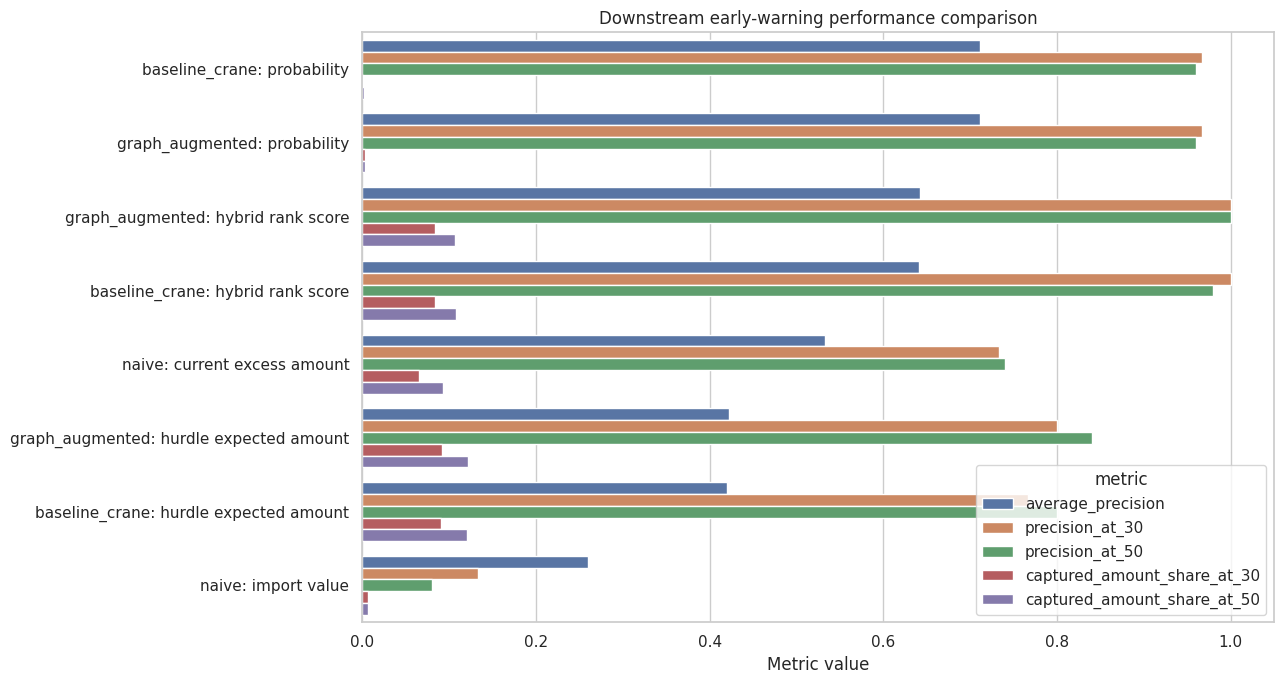

saved figure: figures_factor_graphical/16_downstream_performance_comparison.png bytes= 102447


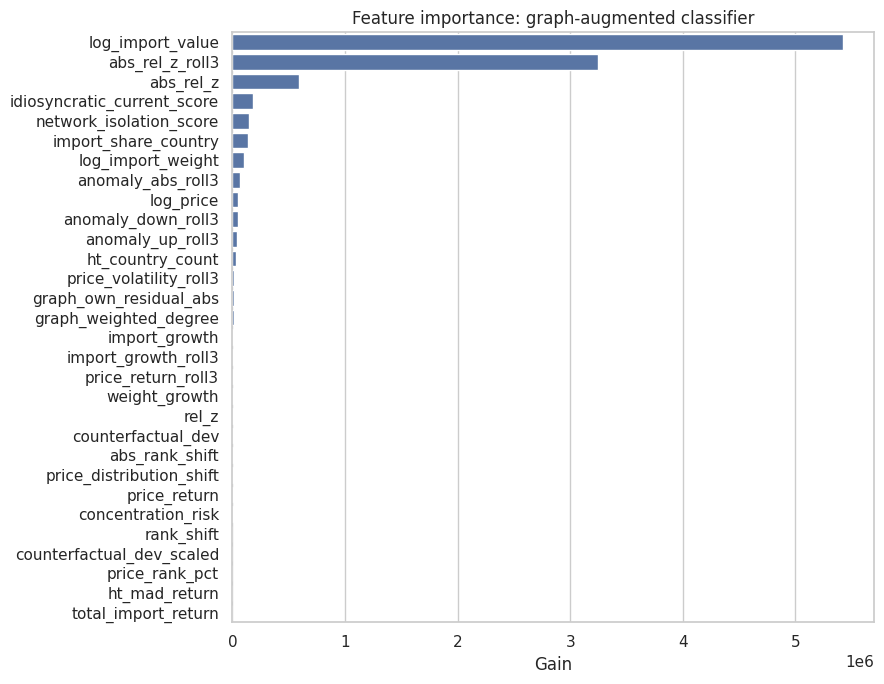

saved figure: figures_factor_graphical/17_feature_importance_graph_augmented_classifier.png bytes= 122285


In [ ]:
# Cell 15. Fit downstream Hurdle models and compare

def fit_hurdle_lgbm(train_df, valid_df, test_df, features, model_name):
    X_train = train_df[features]
    X_valid = valid_df[features]
    X_test = test_df[features]
    y_train_cls = train_df["material_anomaly"].to_numpy(dtype=int)
    y_valid_cls = valid_df["material_anomaly"].to_numpy(dtype=int)

    pos = max(y_train_cls.sum(), 1)
    neg = max(len(y_train_cls) - y_train_cls.sum(), 1)
    clf = lgb.LGBMClassifier(
        objective="binary", num_leaves=31, min_child_samples=40, learning_rate=0.03,
        n_estimators=2000, subsample=0.85, colsample_bytree=0.85,
        scale_pos_weight=neg/pos, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
    )
    clf.fit(X_train, y_train_cls, eval_set=[(X_valid, y_valid_cls)], eval_metric="auc", callbacks=[lgb.early_stopping(stopping_rounds=80, verbose=False)])
    valid_prob = clf.predict_proba(X_valid, num_iteration=clf.best_iteration_)[:, 1]
    test_prob = clf.predict_proba(X_test, num_iteration=clf.best_iteration_)[:, 1]

    sev_train = train_df[train_df["material_anomaly"] == 1].copy()
    sev_valid = valid_df[valid_df["material_anomaly"] == 1].copy()
    if len(sev_train) < 50:
        sev_train = train_df[train_df[target_col] > 0].copy()
    if len(sev_valid) < 30:
        sev_valid = valid_df[valid_df[target_col] > 0].copy()

    if len(sev_train) < 20 or len(sev_valid) < 10:
        print(f"{model_name}: Too few positive samples for severity model. Using median fallback.")
        fallback = max(float(sev_train[target_col].median()), EPS) if len(sev_train) else max(float(train_df[target_col].median()), EPS)
        valid_sev = np.repeat(fallback, len(valid_df))
        test_sev = np.repeat(fallback, len(test_df))
        sev = None
    else:
        sev = lgb.LGBMRegressor(
            objective="tweedie", metric="tweedie", tweedie_variance_power=1.5,
            num_leaves=31, min_child_samples=15, learning_rate=0.03,
            n_estimators=2000, subsample=0.90, colsample_bytree=0.90,
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
        )
        sev.fit(sev_train[features], sev_train[target_col], eval_set=[(sev_valid[features], sev_valid[target_col])], eval_metric="tweedie", callbacks=[lgb.early_stopping(stopping_rounds=80, verbose=False)])
        valid_sev = np.maximum(sev.predict(X_valid, num_iteration=sev.best_iteration_), 0)
        test_sev = np.maximum(sev.predict(X_test, num_iteration=sev.best_iteration_), 0)

    valid_raw = valid_prob * valid_sev
    test_raw = test_prob * test_sev
    scale = valid_df[target_col].sum() / valid_raw.sum() if valid_raw.sum() > 0 else 1.0
    scale = float(np.clip(scale, 0.05, 20.0))
    valid_amount = valid_raw * scale
    test_amount = test_raw * scale

    valid_out = valid_df.copy()
    test_out = test_df.copy()
    for out, prob, sev_pred, amount in [(valid_out, valid_prob, valid_sev, valid_amount), (test_out, test_prob, test_sev, test_amount)]:
        out[f"{model_name}_prob"] = prob
        out[f"{model_name}_severity"] = sev_pred
        out[f"{model_name}_hurdle_amount"] = amount
        out[f"{model_name}_rank_score"] = pct_rank_score(amount) * 0.6 + pct_rank_score(prob) * 0.4

    eval_rows = [
        evaluate_score(test_out, test_out[f"{model_name}_prob"], f"{model_name}: probability", amount_like=False),
        evaluate_score(test_out, test_out[f"{model_name}_hurdle_amount"], f"{model_name}: hurdle expected amount", amount_like=True),
        evaluate_score(test_out, test_out[f"{model_name}_rank_score"], f"{model_name}: hybrid rank score", amount_like=False),
    ]

    clf_imp = pd.DataFrame({"feature": features, "gain": clf.booster_.feature_importance(importance_type="gain"), "split": clf.booster_.feature_importance(importance_type="split"), "model": f"{model_name}_classifier"}).sort_values("gain", ascending=False)
    if sev is not None:
        sev_imp = pd.DataFrame({"feature": features, "gain": sev.booster_.feature_importance(importance_type="gain"), "split": sev.booster_.feature_importance(importance_type="split"), "model": f"{model_name}_severity"}).sort_values("gain", ascending=False)
    else:
        sev_imp = pd.DataFrame(columns=["feature", "gain", "split", "model"])
    return {"clf": clf, "sev": sev, "valid": valid_out, "test": test_out, "eval": pd.DataFrame(eval_rows), "feature_importance": pd.concat([clf_imp, sev_imp], ignore_index=True), "scale": scale}

if RUN_DOWNSTREAM_LIGHTGBM:
    baseline_result = fit_hurdle_lgbm(train_df, valid_df, test_df, base_features, "baseline_crane")
    graph_result = fit_hurdle_lgbm(train_df, valid_df, test_df, base_features + graph_features, "graph_augmented")

    model_comparison = pd.concat([baseline_result["eval"], graph_result["eval"]], ignore_index=True)
    if "import_value" in test_df.columns:
        model_comparison = pd.concat([pd.DataFrame([evaluate_score(test_df, test_df["import_value"], "naive: import value", amount_like=True)]), model_comparison], ignore_index=True)
    if "abs_rel_z" in test_df.columns:
        current_excess = test_df["import_value"] * np.maximum(test_df["abs_rel_z"] - ANOMALY_K, 0)
        model_comparison = pd.concat([pd.DataFrame([evaluate_score(test_df, current_excess, "naive: current excess amount", amount_like=True)]), model_comparison], ignore_index=True)

    model_comparison = model_comparison.sort_values(["average_precision", "precision_at_30"], ascending=False)
    model_comparison.to_csv("output_factor_graphical/downstream_model_comparison.csv", index=False, encoding="utf-8-sig")
    feature_importance_all = pd.concat([baseline_result["feature_importance"], graph_result["feature_importance"]], ignore_index=True)
    feature_importance_all.to_csv("output_factor_graphical/downstream_feature_importance.csv", index=False, encoding="utf-8-sig")
    display(model_comparison)

    metric_cols = ["average_precision", "precision_at_30", "precision_at_50", "captured_amount_share_at_30", "captured_amount_share_at_50"]
    plot_df = model_comparison[["model"] + [c for c in metric_cols if c in model_comparison.columns]].melt(id_vars="model", var_name="metric", value_name="value")
    plt.figure(figsize=(13, 7))
    sns.barplot(data=plot_df, y="model", x="value", hue="metric")
    plt.title("Downstream early-warning performance comparison")
    plt.xlabel("Metric value")
    plt.ylabel("")
    save_fig("figures_factor_graphical/16_downstream_performance_comparison.png")

    imp_graph_clf = feature_importance_all[feature_importance_all["model"] == "graph_augmented_classifier"].copy()
    plt.figure(figsize=(9, 7))
    sns.barplot(data=imp_graph_clf.head(30), y="feature", x="gain")
    plt.title("Feature importance: graph-augmented classifier")
    plt.xlabel("Gain")
    plt.ylabel("")
    save_fig("figures_factor_graphical/17_feature_importance_graph_augmented_classifier.png")
else:
    print("Prediction fitting skipped.")

In [ ]:
# Cell 16. Export final warning list and download outputs if needed
if RUN_DOWNSTREAM_LIGHTGBM:
    final_warning = graph_result["test"].copy().sort_values(["graph_augmented_rank_score", "graph_augmented_hurdle_amount"], ascending=False).reset_index(drop=True)
    final_warning["warning_rank"] = np.arange(1, len(final_warning) + 1)
    warning_cols = [
        "warning_rank", "date", "next_date", "hs_code", "hs_name", "country_code", "country_name",
        "import_value", "import_weight", "unit_price", "rel_z", "next_rel_z", "future_net_anomaly_amount", "material_anomaly",
        "graph_augmented_prob", "graph_augmented_hurdle_amount", "graph_augmented_rank_score",
        "graph_neighbor_risk", "graph_own_residual_abs", "graph_factor_exposure", "graph_weighted_degree", "graph_betweenness", "graph_eigenvector",
    ]
    warning_cols = [c for c in warning_cols if c in final_warning.columns]
    final_warning[warning_cols].to_csv("output_factor_graphical/final_warning_list_graph_augmented.csv", index=False, encoding="utf-8-sig")
    display(final_warning[warning_cols].head(50))

print("Saved core files:")
for p in [
    "data_raw/customs_raw_production.csv",
    "data_processed/trade_clean_production.csv",
    "output_production/crane_features_production.csv",
    "output_factor_graphical/crane_cell_features_with_graph_features.csv",
    "output_factor_graphical/downstream_model_comparison.csv",
    "output_factor_graphical/final_warning_list_graph_augmented.csv",
]:
    path = Path(p)
    print(p, "exists=", path.exists(), "size_MB=", round(path.stat().st_size/1024/1024, 2) if path.exists() else None)

# Colab에서 파일 다운로드가 필요하면 아래 주석을 해제하세요.
# from google.colab import files
# files.download("output_production/crane_features_production.csv")
# files.download("output_factor_graphical/downstream_model_comparison.csv")

,warning_rank,date,next_date,hs_code,hs_name,country_code,country_name,import_value,import_weight,unit_price,rel_z,next_rel_z,future_net_anomaly_amount,material_anomaly,graph_augmented_prob,graph_augmented_hurdle_amount,graph_augmented_rank_score,graph_neighbor_risk,graph_own_residual_abs,graph_factor_exposure,graph_weighted_degree,graph_betweenness,graph_eigenvector
0,1,2024-01-01,2024-02-01,0202,쇠고기(냉동한 것으로 한정한다),US,미국,190561916,24349110,7.826237,6.259132,5.122179,6.902494e+08,1,0.53163,3.532349e+08,0.995668,0.0,0.892402,0.750483,0.0,0.0,0.0
1,2,2024-08-01,2024-09-01,8501,전동기와 발전기(발전세트는 제외한다),PH,필리핀,110540249,67023,1649.288289,9.567248,5.481201,4.400830e+08,1,0.53163,3.476434e+08,0.995665,0.0,2.446042,1.183417,0.0,0.0,0.0
2,3,2024-10-01,2024-11-01,8501,전동기와 발전기(발전세트는 제외한다),PH,필리핀,103275718,61829,1670.344304,5.516625,5.114685,3.733092e+08,1,0.53163,3.399613e+08,0.995662,0.0,0.551094,1.247517,0.0,0.0,0.0
3,4,2024-04-01,2024-05-01,2709,석유와 역청유(瀝靑油)(원유로 한정한다),MX,멕시코,150453057,288365237,0.521745,-3.696519,-2.331907,1.251630e+08,1,0.53163,3.275087e+08,0.995656,0.0,0.077800,0.603695,0.0,0.0,0.0
4,5,2024-07-01,2024-08-01,2709,석유와 역청유(瀝靑油)(원유로 한정한다),MX,멕시코,282645526,493392648,0.572861,-2.961313,-1.772667,7.706824e+07,1,0.53163,3.222837e+08,0.995650,0.0,0.949288,1.290705,0.0,0.0,0.0
5,6,2024-09-01,2024-10-01,8501,전동기와 발전기(발전세트는 제외한다),PH,필리핀,103436367,68029,1520.474606,5.481201,5.516625,4.154651e+08,1,0.53163,3.095870e+08,0.995647,0.0,0.066462,0.921110,0.0,0.0,0.0
6,7,2024-10-01,2024-11-01,2709,석유와 역청유(瀝靑油)(원유로 한정한다),IQ,이라크,564765082,1107082746,0.510138,-3.623601,-2.257602,4.278674e+08,1,0.53163,3.013056e+08,0.995645,0.0,1.304452,1.122514,0.0,0.0,0.0
7,8,2024-07-01,2024-08-01,2607,납광과 그 정광(精鑛),MX,멕시코,173078223,18624910,9.292835,5.305278,5.899105,7.613892e+08,1,0.53163,2.778039e+08,0.995633,0.0,0.535895,1.100414,0.0,0.0,0.0
8,9,2024-05-01,2024-06-01,8541,"반도체 디바이스(예: 다이오드ㆍ트랜지스터ㆍ반도체 기반 트랜스듀서), 감광성 반도체 ...",CN,중국,143994539,14156625,10.171530,-4.339675,-2.740441,1.786167e+08,1,0.53163,2.731249e+08,0.995630,0.0,1.655301,1.037816,0.0,0.0,0.0
9,10,2024-04-01,2024-05-01,8541,"반도체 디바이스(예: 다이오드ㆍ트랜지스터ㆍ반도체 기반 트랜스듀서), 감광성 반도체 ...",CN,중국,134808001,12902041,10.448579,-4.218255,-4.339675,3.828109e+08,1,0.53163,2.553489e+08,0.995621,0.0,1.284374,0.403842,0.0,0.0,0.0


Saved core files:
data_raw/customs_raw_production.csv exists= True size_MB= 607.25
data_processed/trade_clean_production.csv exists= True size_MB= 358.33
output_production/crane_features_production.csv exists= True size_MB= 1328.51
output_factor_graphical/crane_cell_features_with_graph_features.csv exists= True size_MB= 1419.32
output_factor_graphical/downstream_model_comparison.csv exists= True size_MB= 0.0
output_factor_graphical/final_warning_list_graph_augmented.csv exists= True size_MB= 76.3


In [23]:
# %% [markdown]
# ## Regime-switching residual graphical networks
#
# 기존 static network는 2020~2024 전체 기간의 평균적인 조건부 의존 구조를 보여준다.
# 여기서는 기간을 나눠서 공통요인 제거 후 residual network가 시기별로 어떻게 달라지는지 본다.
#
# 핵심 질문:
# - 코로나 시기, 공급망 위기 시기, 정상화 시기에 HS 간 residual dependency가 달라지는가?
# - 특정 시기에 네트워크가 더 dense해지는가?
# - 중심 HS가 시기별로 바뀌는가?
#
# 사용 데이터:
# residual_mat: PCA 공통요인 제거 후 HS별 잔차 u_{h,t}
#
# Regime별 모델:
# u_t^{(r)} ~ N(0, Sigma_u^{(r)})
# Omega_u^{(r)} = Sigma_u^{(r), -1}
#
# Omega_{ij}^{(r)} != 0이면 regime r에서 HS i,j가 조건부 의존.

# %%
from sklearn.covariance import GraphicalLasso
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path

Path("figures_regime_network").mkdir(exist_ok=True)
Path("output_regime_network").mkdir(exist_ok=True)

# -----------------------------
# Regime settings
# -----------------------------
REGIMES = {
    "COVID_2020": ("2020-01-01", "2020-12-31"),
    "SupplyChain_2021_2022": ("2021-01-01", "2022-12-31"),
    "Normalization_2023_2024": ("2023-01-01", "2024-12-31"),
}

# 너무 많은 node를 regime별로 쓰면 T가 작아서 불안정하다.
# 120개 전체보다 수입금액 상위 50개 정도가 안정적이다.
REGIME_MAX_HS_NODES = 50

# Global Graphical LASSO alpha가 있으면 그것을 기준으로 사용.
# Regime별 표본 수가 작으므로 약간 더 보수적으로 키운다.
REGIME_ALPHA_MULTIPLIER = 1.25

# 시각화용 최소 partial correlation threshold.
# 너무 sparse하면 0.02~0.03, 너무 dense하면 0.05 이상으로 조정.
REGIME_EDGE_THRESHOLD = 0.03

# 각 regime 그림에 최대 표시 edge 수.
REGIME_TOP_EDGES_TO_PLOT = 80

# bootstrap은 시간이 오래 걸리므로 일단 False.
RUN_REGIME_BOOTSTRAP = False
REGIME_BOOTSTRAP_B = 50
REGIME_BOOTSTRAP_BLOCK_SIZE = 4

print("Regime network settings ready.")

Regime network settings ready.


In [24]:
# %% [markdown]
# ## Helper functions for regime-specific Graphical LASSO
#
# 이 셀은 regime별 residual matrix를 받아서:
# 1. 표준화
# 2. Graphical LASSO 적합
# 3. partial correlation matrix 계산
# 4. edge table 생성
# 5. centrality 계산
# 을 수행한다.

# %%
def choose_regime_nodes(hs_month_sel, selected_hs, max_nodes=50):
    """
    전체 selected_hs 중에서 수입금액 기준 상위 max_nodes개만 regime network node로 선택한다.
    """
    import_rank = (
        hs_month_sel[hs_month_sel["hs_code"].astype(str).isin([str(x) for x in selected_hs])]
        .groupby("hs_code")["hs_import_value"]
        .sum()
        .sort_values(ascending=False)
    )
    nodes = import_rank.head(max_nodes).index.astype(str).tolist()
    return nodes


def standardize_regime_matrix(X_df):
    """
    regime 내부에서 column-wise standardization.
    결측 또는 0 variance는 0으로 채운다.
    """
    X = X_df.copy().astype(float)
    mu = X.mean(axis=0, skipna=True)
    sd = X.std(axis=0, skipna=True).replace(0, np.nan)
    Z = (X - mu) / sd
    Z = Z.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return Z


def precision_to_partial_corr(precision):
    """
    Precision matrix Omega를 partial correlation matrix로 변환.
    rho_ij = - Omega_ij / sqrt(Omega_ii Omega_jj)
    """
    diag = np.sqrt(np.diag(precision))
    pc = -precision / np.outer(diag, diag)
    np.fill_diagonal(pc, 1.0)
    return pc


def build_edge_table_from_partial(pc_df, threshold=0.03):
    """
    partial correlation matrix에서 edge table 생성.
    """
    hs_codes = list(pc_df.index)
    rows = []
    for i in range(len(hs_codes)):
        for j in range(i + 1, len(hs_codes)):
            pc = float(pc_df.iloc[i, j])
            if np.isfinite(pc) and abs(pc) >= threshold:
                rows.append({
                    "hs_i": hs_codes[i],
                    "hs_j": hs_codes[j],
                    "partial_corr": pc,
                    "abs_partial_corr": abs(pc),
                    "sign": "positive" if pc > 0 else "negative",
                })
    edge_df = pd.DataFrame(rows)
    if len(edge_df) > 0:
        edge_df = edge_df.sort_values("abs_partial_corr", ascending=False).reset_index(drop=True)
    return edge_df


def edge_table_to_graph(edge_df):
    """
    edge table을 networkx Graph로 변환.
    """
    G = nx.Graph()
    if edge_df is None or len(edge_df) == 0:
        return G

    for _, r in edge_df.iterrows():
        G.add_edge(
            str(r["hs_i"]),
            str(r["hs_j"]),
            weight=float(r["abs_partial_corr"]),
            partial_corr=float(r["partial_corr"]),
            sign=str(r["sign"]),
        )
    return G


def compute_graph_centrality(G, regime_name, node_info=None):
    """
    regime graph의 centrality table 생성.
    """
    if G.number_of_nodes() == 0:
        return pd.DataFrame(columns=[
            "regime", "hs_code", "degree", "weighted_degree",
            "betweenness", "component_id", "component_size",
            "mean_Z", "total_import"
        ])

    weighted_degree = dict(G.degree(weight="weight"))
    degree = dict(G.degree())
    betweenness = nx.betweenness_centrality(G, weight="weight") if G.number_of_edges() > 0 else {n: 0 for n in G.nodes()}

    components = list(nx.connected_components(G))
    comp_map = {}
    comp_size = {}
    for k, comp in enumerate(components):
        for node in comp:
            comp_map[node] = k
            comp_size[node] = len(comp)

    rows = []
    for n in G.nodes():
        rows.append({
            "regime": regime_name,
            "hs_code": n,
            "degree": degree.get(n, 0),
            "weighted_degree": weighted_degree.get(n, 0.0),
            "betweenness": betweenness.get(n, 0.0),
            "component_id": comp_map.get(n, -1),
            "component_size": comp_size.get(n, 1),
            "mean_Z": node_info.get(n, {}).get("mean_Z", np.nan) if node_info else np.nan,
            "total_import": node_info.get(n, {}).get("total_import", np.nan) if node_info else np.nan,
        })

    return pd.DataFrame(rows).sort_values(["weighted_degree", "degree"], ascending=False)


def fit_regime_graphical_lasso(
    residual_mat,
    regime_name,
    start_date,
    end_date,
    nodes,
    alpha,
    threshold=0.03,
):
    """
    특정 regime 기간에 대해 residual Graphical LASSO를 적합한다.
    """
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)

    U_regime = residual_mat.copy()
    U_regime.index = pd.to_datetime(U_regime.index)
    U_regime = U_regime.loc[(U_regime.index >= start) & (U_regime.index <= end), nodes]

    if U_regime.shape[0] < 8:
        print(f"[WARNING] {regime_name}: too few months, n={U_regime.shape[0]}")

    U_std = standardize_regime_matrix(U_regime)

    gl = GraphicalLasso(alpha=alpha, max_iter=2000)
    gl.fit(U_std.values)

    precision = gl.precision_
    partial_corr = precision_to_partial_corr(precision)

    pc_df = pd.DataFrame(partial_corr, index=nodes, columns=nodes)
    edge_df = build_edge_table_from_partial(pc_df, threshold=threshold)
    G = edge_table_to_graph(edge_df)

    result = {
        "regime": regime_name,
        "start_date": start,
        "end_date": end,
        "n_months": U_std.shape[0],
        "n_nodes": len(nodes),
        "alpha": alpha,
        "U_std": U_std,
        "precision": precision,
        "partial_corr_df": pc_df,
        "edge_df": edge_df,
        "graph": G,
    }
    return result


# Select regime nodes
regime_nodes = choose_regime_nodes(
    hs_month_sel=hs_month_sel,
    selected_hs=selected_hs,
    max_nodes=REGIME_MAX_HS_NODES
)

print("Regime nodes:", len(regime_nodes))
print(regime_nodes[:20])

# Node info for plotting
node_info_regime = (
    hs_month_sel[hs_month_sel["hs_code"].astype(str).isin(regime_nodes)]
    .groupby("hs_code")
    .agg(
        mean_Z=("Z_ht", "mean"),
        total_import=("hs_import_value", "sum"),
        n_month=("date", "nunique"),
    )
    .to_dict("index")
)

# Pick alpha
if "alpha_selected" in globals():
    regime_alpha = float(alpha_selected) * REGIME_ALPHA_MULTIPLIER
else:
    regime_alpha = 0.10 * REGIME_ALPHA_MULTIPLIER

print("Regime Graphical LASSO alpha:", regime_alpha)

Regime nodes: 50
['2709', '8542', '2711', '2710', '8486', '2701', '8703', '8517', '2601', '8471', '2825', '8541', '2603', '8473', '8507', '3004', '8708', '3002', '9031', '8544']
Regime Graphical LASSO alpha: 0.5228568984900968


In [25]:
# %% [markdown]
# ## Fit regime-specific residual graphical networks
#
# 각 regime에 대해 Graphical LASSO를 따로 적합한다.
# 결과는 output_regime_network/ 아래에 저장된다.

# %%
regime_results = {}

for regime_name, (start_date, end_date) in REGIMES.items():
    print("\n" + "=" * 80)
    print(f"Fitting regime: {regime_name} | {start_date} to {end_date}")

    res = fit_regime_graphical_lasso(
        residual_mat=residual_mat,
        regime_name=regime_name,
        start_date=start_date,
        end_date=end_date,
        nodes=regime_nodes,
        alpha=regime_alpha,
        threshold=REGIME_EDGE_THRESHOLD,
    )

    regime_results[regime_name] = res

    # Save matrices and edges
    res["partial_corr_df"].to_csv(
        f"output_regime_network/{regime_name}_partial_corr.csv",
        encoding="utf-8-sig"
    )

    if len(res["edge_df"]) > 0:
        res["edge_df"].to_csv(
            f"output_regime_network/{regime_name}_edges.csv",
            index=False,
            encoding="utf-8-sig"
        )

    print("n_months:", res["n_months"])
    print("n_nodes:", res["n_nodes"])
    print("n_edges:", len(res["edge_df"]))
    display(res["edge_df"].head(15) if len(res["edge_df"]) > 0 else pd.DataFrame())


Fitting regime: COVID_2020 | 2020-01-01 to 2020-12-31
n_months: 12
n_nodes: 50
n_edges: 63


,hs_i,hs_j,partial_corr,abs_partial_corr,sign
0,2710,8901,-0.268636,0.268636,negative
1,8534,7403,0.255504,0.255504,positive
2,8541,7204,-0.249532,0.249532,negative
3,8517,8471,0.244860,0.244860,positive
4,4202,8534,-0.219160,0.219160,negative
5,2709,1005,-0.198517,0.198517,negative
6,3002,8544,-0.196541,0.196541,negative
7,3002,7601,0.196264,0.196264,positive
8,2825,8802,0.189199,0.189199,positive
9,8473,0202,0.182243,0.182243,positive



Fitting regime: SupplyChain_2021_2022 | 2021-01-01 to 2022-12-31
n_months: 24
n_nodes: 50
n_edges: 2


,hs_i,hs_j,partial_corr,abs_partial_corr,sign
0,2710,8544,0.089556,0.089556,positive
1,3004,8411,0.087409,0.087409,positive



Fitting regime: Normalization_2023_2024 | 2023-01-01 to 2024-12-31
n_months: 24
n_nodes: 50
n_edges: 9


,hs_i,hs_j,partial_corr,abs_partial_corr,sign
0,8523,3818,0.151171,0.151171,positive
1,8411,7204,-0.135432,0.135432,negative
2,7601,9018,0.128697,0.128697,positive
3,2603,8529,0.091032,0.091032,positive
4,8486,8501,-0.077791,0.077791,negative
5,8529,0202,0.059532,0.059532,positive
6,8486,8529,0.051748,0.051748,positive
7,2710,8536,0.043415,0.043415,positive
8,2711,3002,-0.031538,0.031538,negative


In [26]:
# %% [markdown]
# ## Regime network summary metrics
#
# 시기별 네트워크가 얼마나 조밀한지, 중심성이 어떻게 달라지는지 요약한다.

# %%
summary_rows = []
centrality_tables = []

possible_edges = len(regime_nodes) * (len(regime_nodes) - 1) / 2

for regime_name, res in regime_results.items():
    G = res["graph"]
    edge_df = res["edge_df"]

    n_edges = G.number_of_edges()
    n_nodes_connected = G.number_of_nodes()
    density = n_edges / possible_edges if possible_edges > 0 else np.nan

    if len(edge_df) > 0:
        mean_abs_pc = edge_df["abs_partial_corr"].mean()
        max_abs_pc = edge_df["abs_partial_corr"].max()
        positive_share = (edge_df["partial_corr"] > 0).mean()
    else:
        mean_abs_pc = 0.0
        max_abs_pc = 0.0
        positive_share = np.nan

    components = list(nx.connected_components(G)) if G.number_of_nodes() > 0 else []
    largest_component_size = max([len(c) for c in components]) if components else 0

    cent = compute_graph_centrality(G, regime_name, node_info=node_info_regime)
    centrality_tables.append(cent)

    top_node = cent.iloc[0]["hs_code"] if len(cent) > 0 else None
    top_wdegree = cent.iloc[0]["weighted_degree"] if len(cent) > 0 else 0.0

    summary_rows.append({
        "regime": regime_name,
        "start_date": res["start_date"],
        "end_date": res["end_date"],
        "n_months": res["n_months"],
        "n_nodes_total": len(regime_nodes),
        "n_nodes_connected": n_nodes_connected,
        "n_edges": n_edges,
        "edge_density": density,
        "mean_abs_partial_corr": mean_abs_pc,
        "max_abs_partial_corr": max_abs_pc,
        "positive_edge_share": positive_share,
        "n_components": len(components),
        "largest_component_size": largest_component_size,
        "top_central_hs": top_node,
        "top_weighted_degree": top_wdegree,
    })

regime_summary = pd.DataFrame(summary_rows)
regime_centrality = pd.concat(centrality_tables, ignore_index=True) if centrality_tables else pd.DataFrame()

regime_summary.to_csv("output_regime_network/regime_network_summary.csv", index=False, encoding="utf-8-sig")
regime_centrality.to_csv("output_regime_network/regime_network_centrality.csv", index=False, encoding="utf-8-sig")

display(regime_summary)
display(regime_centrality.head(30))

,regime,start_date,end_date,n_months,n_nodes_total,n_nodes_connected,n_edges,edge_density,mean_abs_partial_corr,max_abs_partial_corr,positive_edge_share,n_components,largest_component_size,top_central_hs,top_weighted_degree
0,COVID_2020,2020-01-01,2020-12-31,12,50,45,63,0.051429,0.109120,0.268636,0.492063,3,40,3002,0.755027
1,SupplyChain_2021_2022,2021-01-01,2022-12-31,24,50,4,2,0.001633,0.088483,0.089556,1.000000,2,2,2710,0.089556
2,Normalization_2023_2024,2023-01-01,2024-12-31,24,50,15,9,0.007347,0.085595,0.151171,0.666667,6,5,8529,0.202312


,regime,hs_code,degree,weighted_degree,betweenness,component_id,component_size,mean_Z,total_import
0,COVID_2020,3002,6,0.755027,0.096195,0,40,1.131263,20400993399
1,COVID_2020,2709,7,0.644441,0.188161,0,40,0.952461,388924477700
2,COVID_2020,4202,5,0.621575,0.135307,0,40,2.061739,17612069604
3,COVID_2020,1005,5,0.620513,0.169133,0,40,0.868983,16307891254
4,COVID_2020,8901,4,0.587186,0.040169,0,40,1.132927,11313957768
5,COVID_2020,8528,5,0.555962,0.199789,0,40,1.475545,10756013118
6,COVID_2020,7601,5,0.517766,0.031712,0,40,0.475198,18879017193
7,COVID_2020,7204,4,0.502506,0.084567,0,40,0.739702,9968521732
8,COVID_2020,8534,2,0.474664,0.000000,0,40,1.207470,14811256378
9,COVID_2020,8802,3,0.468127,0.000000,0,40,3.489594,9438287688


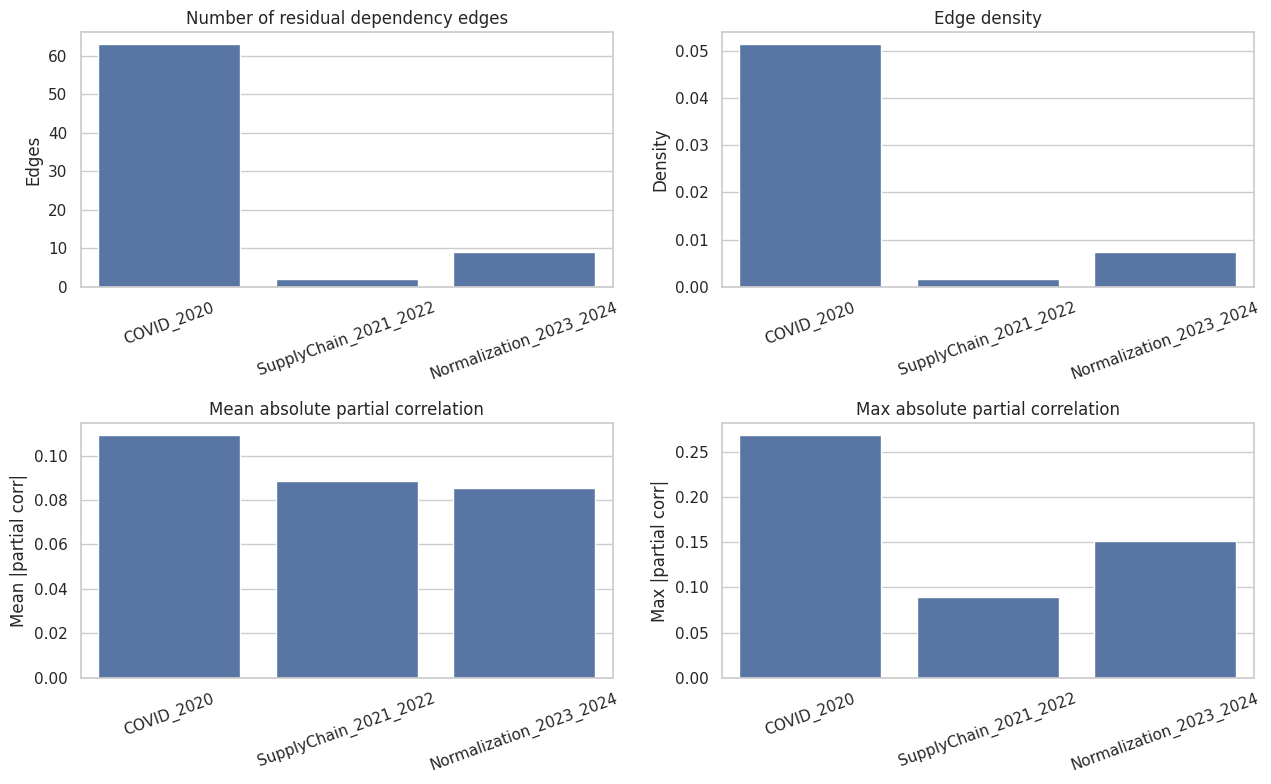

In [27]:
# %% [markdown]
# ## Visualize regime-level network metrics
#
# 시기별 edge 수, density, 평균 partial correlation, 최대 partial correlation을 비교한다.

# %%
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.barplot(data=regime_summary, x="regime", y="n_edges", ax=axes[0, 0])
axes[0, 0].set_title("Number of residual dependency edges")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Edges")
axes[0, 0].tick_params(axis="x", rotation=20)

sns.barplot(data=regime_summary, x="regime", y="edge_density", ax=axes[0, 1])
axes[0, 1].set_title("Edge density")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Density")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.barplot(data=regime_summary, x="regime", y="mean_abs_partial_corr", ax=axes[1, 0])
axes[1, 0].set_title("Mean absolute partial correlation")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Mean |partial corr|")
axes[1, 0].tick_params(axis="x", rotation=20)

sns.barplot(data=regime_summary, x="regime", y="max_abs_partial_corr", ax=axes[1, 1])
axes[1, 1].set_title("Max absolute partial correlation")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Max |partial corr|")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("figures_regime_network/01_regime_network_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

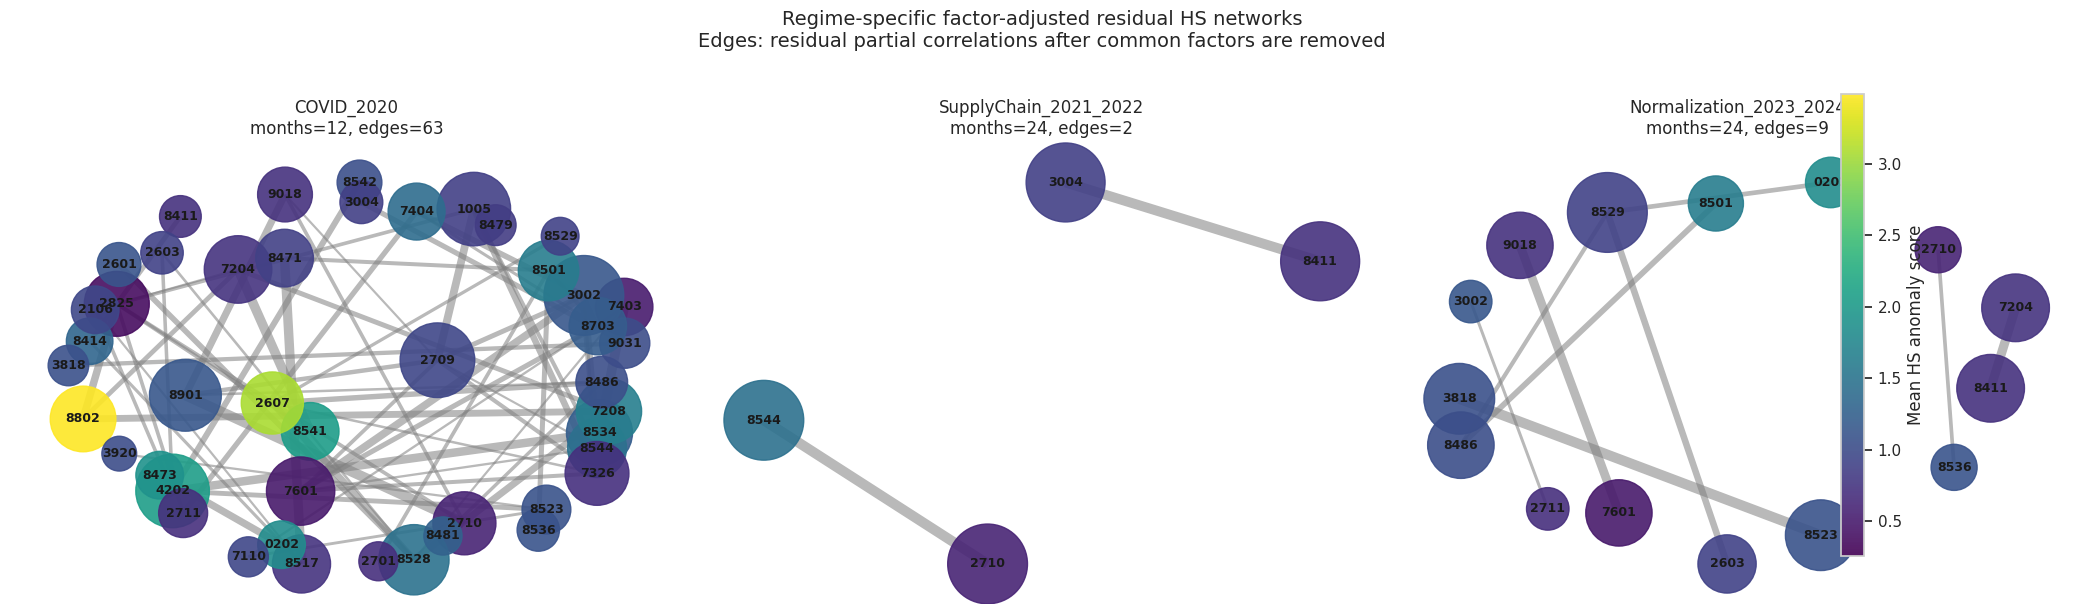

In [28]:
# %% [markdown]
# ## Plot regime-specific residual conditional-dependence networks
#
# 세 regime의 residual conditional-dependence network를 나란히 비교한다.
#
# Node size: weighted degree
# Node color: mean HS anomaly score
# Edge width: absolute residual partial correlation

# %%
def plot_regime_network_panel(regime_results, node_info, max_edges=80):
    n_regimes = len(regime_results)
    fig, axes = plt.subplots(1, n_regimes, figsize=(7 * n_regimes, 6))

    if n_regimes == 1:
        axes = [axes]

    # 공통 color scale
    mean_z_values = [node_info.get(n, {}).get("mean_Z", np.nan) for n in regime_nodes]
    vmin = np.nanmin(mean_z_values)
    vmax = np.nanmax(mean_z_values)

    for ax, (regime_name, res) in zip(axes, regime_results.items()):
        edge_df = res["edge_df"].copy()

        if len(edge_df) > max_edges:
            edge_df = edge_df.sort_values("abs_partial_corr", ascending=False).head(max_edges)

        G = edge_table_to_graph(edge_df)

        if G.number_of_edges() == 0:
            ax.text(0.5, 0.5, "No edges", ha="center", va="center", fontsize=14)
            ax.set_title(f"{regime_name}\nNo residual edges")
            ax.axis("off")
            continue

        pos = nx.spring_layout(G, seed=123, k=0.9)

        wdeg = dict(G.degree(weight="weight"))
        max_wdeg = max(wdeg.values()) if wdeg else 1.0
        node_sizes = [500 + 2800 * wdeg.get(n, 0.0) / max_wdeg for n in G.nodes()]

        node_colors = [node_info.get(n, {}).get("mean_Z", np.nan) for n in G.nodes()]

        edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
        max_edge_w = max(edge_weights) if edge_weights else 1.0
        edge_widths = [0.8 + 6.5 * w / max_edge_w for w in edge_weights]

        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            width=edge_widths,
            edge_color="gray",
            alpha=0.55,
        )

        nodes = nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            node_size=node_sizes,
            node_color=node_colors,
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
            alpha=0.9,
        )

        nx.draw_networkx_labels(
            G,
            pos,
            ax=ax,
            font_size=9,
            font_weight="bold",
        )

        ax.set_title(
            f"{regime_name}\n"
            f"months={res['n_months']}, edges={G.number_of_edges()}"
        )
        ax.axis("off")

    cbar = fig.colorbar(nodes, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label("Mean HS anomaly score")

    plt.suptitle(
        "Regime-specific factor-adjusted residual HS networks\n"
        "Edges: residual partial correlations after common factors are removed",
        y=1.02,
        fontsize=14,
    )
    plt.tight_layout()
    plt.savefig("figures_regime_network/02_regime_networks_panel.png", dpi=160, bbox_inches="tight")
    plt.show()


plot_regime_network_panel(regime_results, node_info_regime, max_edges=REGIME_TOP_EDGES_TO_PLOT)

,hs_i,hs_j,partial_corr,abs_partial_corr,sign,regime,edge,rank_in_regime
0,2710,8901,-0.268636,0.268636,negative,COVID_2020,2710-8901,1
1,8534,7403,0.255504,0.255504,positive,COVID_2020,7403-8534,2
2,8541,7204,-0.249532,0.249532,negative,COVID_2020,7204-8541,3
3,8517,8471,0.244860,0.244860,positive,COVID_2020,8471-8517,4
4,4202,8534,-0.219160,0.219160,negative,COVID_2020,4202-8534,5
5,2709,1005,-0.198517,0.198517,negative,COVID_2020,1005-2709,6
6,3002,8544,-0.196541,0.196541,negative,COVID_2020,3002-8544,7
7,3002,7601,0.196264,0.196264,positive,COVID_2020,3002-7601,8
8,2825,8802,0.189199,0.189199,positive,COVID_2020,2825-8802,9
9,8473,0202,0.182243,0.182243,positive,COVID_2020,0202-8473,10


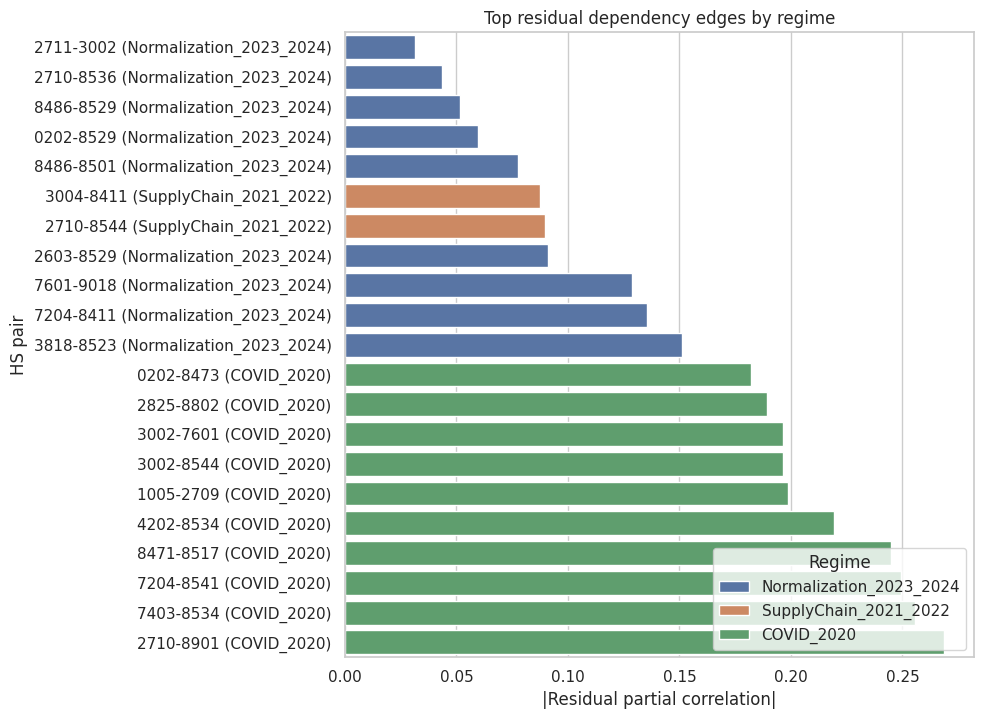

In [29]:
# %% [markdown]
# ## Top residual dependency edges by regime
#
# 시기별로 어떤 HS pair가 강하게 연결되는지 비교한다.

# %%
top_edge_tables = []

for regime_name, res in regime_results.items():
    edge_df = res["edge_df"].copy()
    if len(edge_df) == 0:
        continue

    edge_df["regime"] = regime_name
    edge_df["edge"] = edge_df.apply(lambda r: "-".join(sorted([str(r["hs_i"]), str(r["hs_j"])])), axis=1)
    edge_df["rank_in_regime"] = np.arange(1, len(edge_df) + 1)
    top_edge_tables.append(edge_df.head(20))

regime_top_edges = pd.concat(top_edge_tables, ignore_index=True) if top_edge_tables else pd.DataFrame()
regime_top_edges.to_csv("output_regime_network/regime_top_edges.csv", index=False, encoding="utf-8-sig")

display(regime_top_edges)

# Plot top 10 edges per regime
if len(regime_top_edges) > 0:
    plot_edges = regime_top_edges[regime_top_edges["rank_in_regime"] <= 10].copy()
    plot_edges["edge_label"] = plot_edges["edge"] + " (" + plot_edges["regime"] + ")"

    plt.figure(figsize=(10, max(5, 0.35 * len(plot_edges))))
    sns.barplot(
        data=plot_edges.sort_values("abs_partial_corr", ascending=True),
        y="edge_label",
        x="abs_partial_corr",
        hue="regime",
        dodge=False,
    )
    plt.title("Top residual dependency edges by regime")
    plt.xlabel("|Residual partial correlation|")
    plt.ylabel("HS pair")
    plt.legend(title="Regime", loc="lower right")
    plt.tight_layout()
    plt.savefig("figures_regime_network/03_top_edges_by_regime.png", dpi=160, bbox_inches="tight")
    plt.show()

,COVID_2020,SupplyChain_2021_2022,Normalization_2023_2024
COVID_2020,1.0,0.0,0.0
SupplyChain_2021_2022,0.0,1.0,0.0
Normalization_2023_2024,0.0,0.0,1.0


,COVID_2020,SupplyChain_2021_2022,Normalization_2023_2024
COVID_2020,63.0,0.0,0.0
SupplyChain_2021_2022,0.0,2.0,0.0
Normalization_2023_2024,0.0,0.0,9.0


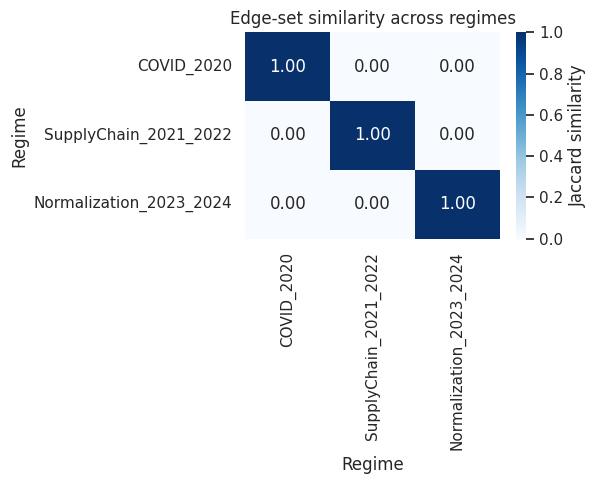

Regime-specific unique edges:


,hs_i,hs_j,partial_corr,abs_partial_corr,sign,edge_tuple,regime
0,2710,8901,-0.268636,0.268636,negative,"(2710, 8901)",COVID_2020
1,8534,7403,0.255504,0.255504,positive,"(7403, 8534)",COVID_2020
2,8541,7204,-0.249532,0.249532,negative,"(7204, 8541)",COVID_2020
3,8517,8471,0.244860,0.244860,positive,"(8471, 8517)",COVID_2020
4,4202,8534,-0.219160,0.219160,negative,"(4202, 8534)",COVID_2020
5,2709,1005,-0.198517,0.198517,negative,"(1005, 2709)",COVID_2020
6,3002,8544,-0.196541,0.196541,negative,"(3002, 8544)",COVID_2020
7,3002,7601,0.196264,0.196264,positive,"(3002, 7601)",COVID_2020
8,2825,8802,0.189199,0.189199,positive,"(2825, 8802)",COVID_2020
9,8473,0202,0.182243,0.182243,positive,"(0202, 8473)",COVID_2020


In [30]:
# %% [markdown]
# ## Edge turnover across regimes
#
# regime별 edge set이 얼마나 겹치는지 비교한다.
#
# Jaccard similarity:
# J(E_a, E_b) = |E_a ∩ E_b| / |E_a ∪ E_b|
#
# 값이 낮으면 시기별 네트워크 구조가 많이 바뀐다는 뜻이다.

# %%
def canonical_edge_set(edge_df):
    if edge_df is None or len(edge_df) == 0:
        return set()
    return set(
        edge_df.apply(lambda r: tuple(sorted([str(r["hs_i"]), str(r["hs_j"])])), axis=1).tolist()
    )

edge_sets = {
    regime_name: canonical_edge_set(res["edge_df"])
    for regime_name, res in regime_results.items()
}

regime_names = list(edge_sets.keys())
jaccard = pd.DataFrame(index=regime_names, columns=regime_names, dtype=float)
overlap_count = pd.DataFrame(index=regime_names, columns=regime_names, dtype=float)

for a in regime_names:
    for b in regime_names:
        Ea = edge_sets[a]
        Eb = edge_sets[b]
        union = Ea | Eb
        inter = Ea & Eb
        jaccard.loc[a, b] = len(inter) / len(union) if len(union) > 0 else np.nan
        overlap_count.loc[a, b] = len(inter)

jaccard.to_csv("output_regime_network/regime_edge_jaccard.csv", encoding="utf-8-sig")
overlap_count.to_csv("output_regime_network/regime_edge_overlap_count.csv", encoding="utf-8-sig")

display(jaccard)
display(overlap_count)

plt.figure(figsize=(6, 5))
sns.heatmap(
    jaccard,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Jaccard similarity"},
)
plt.title("Edge-set similarity across regimes")
plt.xlabel("Regime")
plt.ylabel("Regime")
plt.tight_layout()
plt.savefig("figures_regime_network/04_regime_edge_jaccard.png", dpi=160, bbox_inches="tight")
plt.show()

# Edges unique to each regime
unique_rows = []
for regime_name in regime_names:
    others = set().union(*[edge_sets[r] for r in regime_names if r != regime_name])
    unique_edges = edge_sets[regime_name] - others

    edge_df = regime_results[regime_name]["edge_df"].copy()
    if len(edge_df) == 0:
        continue

    edge_df["edge_tuple"] = edge_df.apply(lambda r: tuple(sorted([str(r["hs_i"]), str(r["hs_j"])])), axis=1)
    edge_df_unique = edge_df[edge_df["edge_tuple"].isin(unique_edges)].copy()
    edge_df_unique["regime"] = regime_name
    unique_rows.append(edge_df_unique)

regime_unique_edges = pd.concat(unique_rows, ignore_index=True) if unique_rows else pd.DataFrame()
regime_unique_edges.to_csv("output_regime_network/regime_unique_edges.csv", index=False, encoding="utf-8-sig")

print("Regime-specific unique edges:")
display(regime_unique_edges.sort_values(["regime", "abs_partial_corr"], ascending=[True, False]).head(50))

,regime,hs_code,degree,weighted_degree,betweenness,component_id,component_size,mean_Z,total_import
0,COVID_2020,3002,6,0.755027,0.096195,0,40,1.131263,20400993399
1,COVID_2020,2709,7,0.644441,0.188161,0,40,0.952461,388924477700
2,COVID_2020,4202,5,0.621575,0.135307,0,40,2.061739,17612069604
3,COVID_2020,1005,5,0.620513,0.169133,0,40,0.868983,16307891254
4,COVID_2020,8901,4,0.587186,0.040169,0,40,1.132927,11313957768
5,COVID_2020,8528,5,0.555962,0.199789,0,40,1.475545,10756013118
6,COVID_2020,7601,5,0.517766,0.031712,0,40,0.475198,18879017193
7,COVID_2020,7204,4,0.502506,0.084567,0,40,0.739702,9968521732
8,COVID_2020,8534,2,0.474664,0.000000,0,40,1.207470,14811256378
9,COVID_2020,8802,3,0.468127,0.000000,0,40,3.489594,9438287688


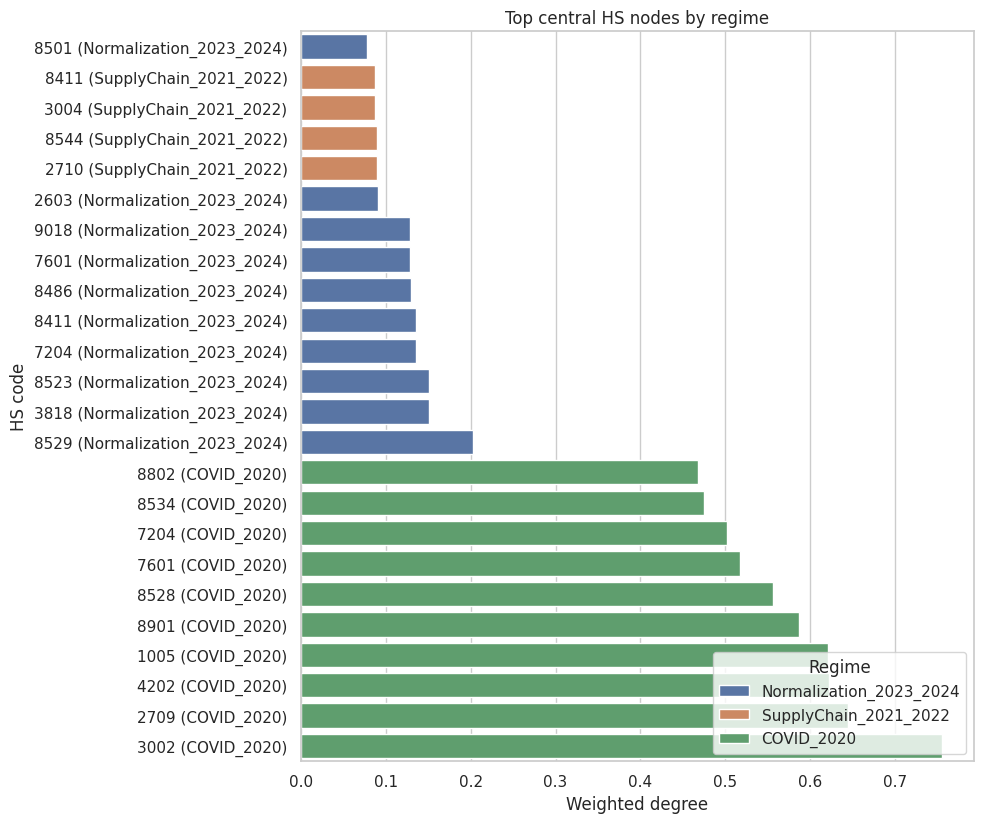

In [31]:
# %% [markdown]
# ## Central HS nodes by regime
#
# 각 regime에서 weighted degree가 높은 HS를 비교한다.
# 중심 HS가 바뀌면 시기별 구조적 취약 품목이 달라졌다는 해석이 가능하다.

# %%
top_central_by_regime = (
    regime_centrality
    .sort_values(["regime", "weighted_degree"], ascending=[True, False])
    .groupby("regime")
    .head(10)
    .copy()
)

top_central_by_regime.to_csv(
    "output_regime_network/top_central_hs_by_regime.csv",
    index=False,
    encoding="utf-8-sig"
)

display(top_central_by_regime)

plt.figure(figsize=(10, max(5, 0.35 * len(top_central_by_regime))))
top_central_by_regime["label"] = (
    top_central_by_regime["hs_code"].astype(str)
    + " ("
    + top_central_by_regime["regime"].astype(str)
    + ")"
)

sns.barplot(
    data=top_central_by_regime.sort_values("weighted_degree", ascending=True),
    y="label",
    x="weighted_degree",
    hue="regime",
    dodge=False,
)

plt.title("Top central HS nodes by regime")
plt.xlabel("Weighted degree")
plt.ylabel("HS code")
plt.legend(title="Regime", loc="lower right")
plt.tight_layout()
plt.savefig("figures_regime_network/05_top_central_hs_by_regime.png", dpi=160, bbox_inches="tight")
plt.show()

In [32]:
# %% [markdown]
# ## Auto-generate interpretation text
#
# 보고서/발표에 넣을 수 있는 regime network 해석 문장을 자동 생성한다.

# %%
def generate_regime_interpretation(regime_summary, regime_top_edges, jaccard):
    lines = []

    lines.append("Regime-specific residual graphical network interpretation")
    lines.append("=" * 70)
    lines.append("")
    lines.append(
        "We estimate separate factor-adjusted residual conditional-dependence networks "
        "for COVID, supply-chain disruption, and normalization regimes. "
        "Edges represent nonzero residual partial correlations after common factors are removed."
    )
    lines.append("")

    for _, r in regime_summary.iterrows():
        regime = r["regime"]
        lines.append(f"[{regime}]")
        lines.append(
            f"- Period: {pd.to_datetime(r['start_date']).date()} to {pd.to_datetime(r['end_date']).date()}, "
            f"months={int(r['n_months'])}"
        )
        lines.append(
            f"- Edges={int(r['n_edges'])}, edge density={r['edge_density']:.4f}, "
            f"mean |partial corr|={r['mean_abs_partial_corr']:.3f}, "
            f"max |partial corr|={r['max_abs_partial_corr']:.3f}"
        )
        lines.append(
            f"- Top central HS: {r['top_central_hs']} "
            f"(weighted degree={r['top_weighted_degree']:.3f})"
        )

        if len(regime_top_edges) > 0:
            top_edges = regime_top_edges[regime_top_edges["regime"] == regime].head(3)
            if len(top_edges) > 0:
                edge_text = ", ".join([
                    f"{row['hs_i']}-{row['hs_j']} ({row['partial_corr']:.3f})"
                    for _, row in top_edges.iterrows()
                ])
                lines.append(f"- Top residual dependency edges: {edge_text}")

        lines.append("")

    lines.append("Edge-set similarity across regimes:")
    lines.append(jaccard.round(3).to_string())
    lines.append("")
    lines.append(
        "Interpretation caution: these are undirected conditional-dependence networks, "
        "not causal transmission networks. A regime-specific edge means that two HS nodes "
        "remain conditionally dependent after common factors and other HS nodes are controlled."
    )

    return "\n".join(lines)


interpretation_text = generate_regime_interpretation(
    regime_summary=regime_summary,
    regime_top_edges=regime_top_edges,
    jaccard=jaccard,
)

print(interpretation_text)

with open("output_regime_network/regime_network_interpretation.txt", "w", encoding="utf-8") as f:
    f.write(interpretation_text)

Regime-specific residual graphical network interpretation

We estimate separate factor-adjusted residual conditional-dependence networks for COVID, supply-chain disruption, and normalization regimes. Edges represent nonzero residual partial correlations after common factors are removed.

[COVID_2020]
- Period: 2020-01-01 to 2020-12-31, months=12
- Edges=63, edge density=0.0514, mean |partial corr|=0.109, max |partial corr|=0.269
- Top central HS: 3002 (weighted degree=0.755)
- Top residual dependency edges: 2710-8901 (-0.269), 8534-7403 (0.256), 8541-7204 (-0.250)

[SupplyChain_2021_2022]
- Period: 2021-01-01 to 2022-12-31, months=24
- Edges=2, edge density=0.0016, mean |partial corr|=0.088, max |partial corr|=0.090
- Top central HS: 2710 (weighted degree=0.090)
- Top residual dependency edges: 2710-8544 (0.090), 3004-8411 (0.087)

[Normalization_2023_2024]
- Period: 2023-01-01 to 2024-12-31, months=24
- Edges=9, edge density=0.0073, mean |partial corr|=0.086, max |partial corr|=0.151
